# MATH 110: Low-Rank Compression and LoRA on Fashion-MNIST

This notebook implements one reproducible experiment with two connected branches:

1. **Part I — Post hoc compression:** train a full-rank Fashion-MNIST MLP, analyze the singular values of its first two weight matrices, replace those matrices by truncated-SVD factorizations, and measure reconstruction error, accuracy, and parameter count **without retraining**.
2. **Part II — Low-rank adaptation:** adapt the same source checkpoint to a deterministic $+20^\circ$ rotated Fashion-MNIST task, compare full-rank references, compress the selected-layer full-rank update with SVD, and train rank-matched LoRA adapters directly.

The selected matrices are

\[
W_1\in\mathbb{R}^{256\times 784},\qquad
W_2\in\mathbb{R}^{128\times 256}.
\]

The notebook keeps the official 10,000-image Fashion-MNIST test set separate from training and checkpoint selection. The test sets are never passed to a training or learning-rate-selection function.


## Experiment map

```text
Fashion-MNIST source data
        │
        ▼
Train full-rank source baseline W₀
        │
        ├── Part I: Post hoc compression of W₀
        │      ├── Singular-value analysis of W₁ and W₂
        │      ├── Eckart–Young numerical verification
        │      ├── W₁-only compression
        │      ├── W₂-only compression
        │      └── Joint compression
        │
        └── Part II: Adaptation to rotated Fashion-MNIST
               ├── Zero-shot evaluation of W₀
               ├── Unrestricted full-model fine-tuning
               ├── Layer-matched full-rank adaptation
               ├── SVD compression of the full-rank updates
               └── Directly learned LoRA updates
```

# 1. Colab environment

In [1]:
# Mount Google Drive when running in Colab.
try:
    from google.colab import drive

    drive.mount("/content/drive", force_remount=False)
    IN_COLAB = True
except ImportError:
    IN_COLAB = False
    print("google.colab is unavailable; using the local working directory.")


google.colab is unavailable; using the local working directory.


In [2]:
from __future__ import annotations

import copy
import hashlib
import json
import math
import os
import platform
import random
import shutil
import sys
from pathlib import Path
from typing import Any, Dict, Iterable, List, Optional, Sequence, Tuple

# Set before CUDA libraries are initialized.
os.environ.setdefault("CUBLAS_WORKSPACE_CONFIG", ":4096:8")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms.functional as TF
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import datasets, transforms
from torchvision.transforms import InterpolationMode
from IPython.display import display


In [3]:
# Record environment information before any training begins.
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
GPU_NAME = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None"

ENVIRONMENT_INFO = {
    "python_version": sys.version.replace("\n", " "),
    "platform": platform.platform(),
    "pytorch_version": torch.__version__,
    "torchvision_version": torchvision.__version__,
    "numpy_version": np.__version__,
    "pandas_version": pd.__version__,
    "cuda_available": torch.cuda.is_available(),
    "gpu_name": GPU_NAME,
    "device": str(DEVICE),
}

print(json.dumps(ENVIRONMENT_INFO, indent=2))


{
  "python_version": "3.9.6 (default, May 22 2026, 11:13:45)  [Clang 21.0.0 (clang-2100.1.1.101)]",
  "platform": "macOS-26.5.2-arm64-arm-64bit",
  "pytorch_version": "2.5.1",
  "torchvision_version": "0.20.1",
  "numpy_version": "2.0.2",
  "pandas_version": "2.2.3",
  "cuda_available": false,
  "gpu_name": "None",
  "device": "cpu"
}


In [4]:
# Final submissions must leave FAST_DEV_RUN set to False.
FAST_DEV_RUN = False
PROJECT_NAME = "MATH110_low_rank_combined"
PROJECT_VERSION = "v1"

if IN_COLAB and Path("/content/drive/MyDrive").exists():
    DRIVE_HOME = Path("/content/drive/MyDrive")
else:
    DRIVE_HOME = Path.cwd()

PROJECT_ROOT = DRIVE_HOME / PROJECT_NAME
RUN_ROOT = PROJECT_ROOT / "development" if FAST_DEV_RUN else PROJECT_ROOT
DATA_ROOT = Path("/content/data") if Path("/content").exists() else RUN_ROOT / "data"

CONFIG_DIR = RUN_ROOT / "config"
CHECKPOINT_DIR = RUN_ROOT / "checkpoints"
LORA_CHECKPOINT_DIR = CHECKPOINT_DIR / "lora"
RESULTS_DIR = RUN_ROOT / "results"
FIGURE_DIR = RUN_ROOT / "figures"
SOURCE_FIGURE_DIR = FIGURE_DIR / "source_compression"
ADAPTATION_FIGURE_DIR = FIGURE_DIR / "adaptation"
LOG_DIR = RUN_ROOT / "logs"

for directory in (
    DATA_ROOT,
    CONFIG_DIR,
    CHECKPOINT_DIR,
    LORA_CHECKPOINT_DIR,
    RESULTS_DIR,
    SOURCE_FIGURE_DIR,
    ADAPTATION_FIGURE_DIR,
    LOG_DIR,
):
    directory.mkdir(parents=True, exist_ok=True)

(CONFIG_DIR / "environment.txt").write_text(
    json.dumps(ENVIRONMENT_INFO, indent=2), encoding="utf-8"
)
print(f"Run directory: {RUN_ROOT}")


Run directory: /Users/arhaan/Downloads/MATH110_low_rank_combined


# 2. Central configuration

In [5]:
CONFIG: Dict[str, Any] = {
    "project_name": PROJECT_NAME,
    "project_version": PROJECT_VERSION,
    "fast_dev_run": FAST_DEV_RUN,
    "seed": 42,
    "split_seed": 42,
    "loader_seed": 42,
    "lora_initialization_seed": 42,
    "batch_size": 128,
    "source_epochs": 20,
    "adaptation_epochs": 15,
    "source_learning_rate": 1e-3,
    "target_learning_rate": 1e-3,
    "lora_learning_rate_candidates": [1e-3, 3e-3],
    "lora_pilot_rank": 16,
    "lora_selected_learning_rate": None,
    "weight_decay": 0.0,
    "rotation_degrees": 20.0,
    "normalization_mean": [0.5],
    "normalization_std": [0.5],
    "source_train_size": 54_000,
    "source_validation_size": 6_000,
    "official_test_size": 10_000,
    "num_workers": 0,
    "reuse_cached_checkpoints": True,
    "training_dtype": "float32",
    "analysis_dtype": "float64",
    "w1_fixed_grid": [1, 2, 4, 8, 16, 32, 48, 64, 80, 96, 112, 128, 160, 192, 224, 256],
    "w2_fixed_grid": [1, 2, 4, 8, 16, 32, 48, 64, 80, 85, 96, 112, 128],
    "joint_fixed_grid": [1, 2, 4, 8, 16, 32, 48, 64, 80, 85, 96, 112, 128],
    "adaptation_same_rank_grid": [1, 2, 4, 8, 16, 32, 64, 96, 128],
    "energy_thresholds": [0.90, 0.95, 0.99],
    "project_root": str(PROJECT_ROOT),
    "run_root": str(RUN_ROOT),
    "data_root": str(DATA_ROOT),
    "device": str(DEVICE),
}


In [6]:
# Development mode is deliberately smaller and writes to its own directory.
if CONFIG["fast_dev_run"]:
    CONFIG.update(
        {
            "source_train_size": 4_096,
            "source_validation_size": 1_024,
            "source_epochs": 2,
            "adaptation_epochs": 2,
            "w1_fixed_grid": [4, 16],
            "w2_fixed_grid": [4, 16],
            "joint_fixed_grid": [4, 16],
            "adaptation_same_rank_grid": [4, 16],
        }
    )

assert CONFIG["source_train_size"] + CONFIG["source_validation_size"] <= 60_000
assert CONFIG["num_workers"] == 0, "The final reproducibility run requires num_workers=0."
print(json.dumps(CONFIG, indent=2))


{
  "project_name": "MATH110_low_rank_combined",
  "project_version": "v1",
  "fast_dev_run": false,
  "seed": 42,
  "split_seed": 42,
  "loader_seed": 42,
  "lora_initialization_seed": 42,
  "batch_size": 128,
  "source_epochs": 20,
  "adaptation_epochs": 15,
  "source_learning_rate": 0.001,
  "target_learning_rate": 0.001,
  "lora_learning_rate_candidates": [
    0.001,
    0.003
  ],
  "lora_pilot_rank": 16,
  "lora_selected_learning_rate": null,
  "weight_decay": 0.0,
  "rotation_degrees": 20.0,
  "normalization_mean": [
    0.5
  ],
  "normalization_std": [
    0.5
  ],
  "source_train_size": 54000,
  "source_validation_size": 6000,
  "official_test_size": 10000,
  "num_workers": 0,
  "reuse_cached_checkpoints": true,
  "training_dtype": "float32",
  "analysis_dtype": "float64",
  "w1_fixed_grid": [
    1,
    2,
    4,
    8,
    16,
    32,
    48,
    64,
    80,
    96,
    112,
    128,
    160,
    192,
    224,
    256
  ],
  "w2_fixed_grid": [
    1,
    2,
    4,
    8,
 

In [7]:
def _signature_payload(config: Dict[str, Any]) -> Dict[str, Any]:
    payload = copy.deepcopy(config)
    # This value is chosen later by the validation-only pilot and must not
    # invalidate checkpoints created before the pilot.
    payload.pop("lora_selected_learning_rate", None)
    payload.pop("config_signature", None)
    return payload


def compute_config_signature(config: Dict[str, Any]) -> str:
    serialized = json.dumps(_signature_payload(config), sort_keys=True)
    return hashlib.sha256(serialized.encode("utf-8")).hexdigest()[:16]


CONFIG_SIGNATURE = compute_config_signature(CONFIG)
CONFIG["config_signature"] = CONFIG_SIGNATURE

with (CONFIG_DIR / "experiment_config.json").open("w", encoding="utf-8") as handle:
    json.dump(CONFIG, handle, indent=2)

print(f"Configuration signature: {CONFIG_SIGNATURE}")


Configuration signature: 27036506a35f2930


# 3. Reproducibility utilities

The same functions seed Python, NumPy, CPU PyTorch, CUDA PyTorch, dataset splitting, DataLoader shuffling, and LoRA initialization. Target-training DataLoaders are recreated with the same shuffle seed for every adaptation method.


In [8]:
def seed_everything(seed: int) -> None:
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)


seed_everything(CONFIG["seed"])


In [9]:
# Prefer deterministic kernels and disable algorithm benchmarking.
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.backends.cuda.matmul.allow_tf32 = False
torch.backends.cudnn.allow_tf32 = False
torch.set_float32_matmul_precision("highest")
try:
    torch.use_deterministic_algorithms(True, warn_only=True)
except TypeError:
    torch.use_deterministic_algorithms(True)

print("Deterministic settings configured.")


Deterministic settings configured.


In [10]:
def make_generator(seed: int) -> torch.Generator:
    generator = torch.Generator()
    generator.manual_seed(seed)
    return generator


def safe_torch_load(path: Path) -> Any:
    try:
        return torch.load(path, map_location="cpu", weights_only=False)
    except TypeError:
        return torch.load(path, map_location="cpu")


# 4. Dataset construction

The original 60,000 Fashion-MNIST training images are split by a saved seed-42 permutation. Source and target subsets reuse the exact same indices. The target transform is a deterministic $+20^\circ$ bilinear rotation with `expand=False` and zero fill, followed by the same tensor conversion and normalization as the source data.


In [11]:
# Generate or reload the deterministic train/validation split.
raw_training_dataset = datasets.FashionMNIST(
    root=DATA_ROOT, train=True, download=True
)
assert len(raw_training_dataset) == 60_000

train_indices_path = CONFIG_DIR / "train_indices.pt"
validation_indices_path = CONFIG_DIR / "validation_indices.pt"

if train_indices_path.exists() and validation_indices_path.exists():
    train_indices = safe_torch_load(train_indices_path).to(torch.long)
    validation_indices = safe_torch_load(validation_indices_path).to(torch.long)
else:
    permutation = torch.randperm(60_000, generator=make_generator(CONFIG["split_seed"]))
    train_end = CONFIG["source_train_size"]
    validation_end = train_end + CONFIG["source_validation_size"]
    train_indices = permutation[:train_end]
    validation_indices = permutation[train_end:validation_end]
    torch.save(train_indices, train_indices_path)
    torch.save(validation_indices, validation_indices_path)

assert len(train_indices) == CONFIG["source_train_size"]
assert len(validation_indices) == CONFIG["source_validation_size"]


100.0%


Extracting /Users/arhaan/Downloads/MATH110_low_rank_combined/data/FashionMNIST/raw/train-images-idx3-ubyte.gz to /Users/arhaan/Downloads/MATH110_low_rank_combined/data/FashionMNIST/raw



100.0%


Extracting /Users/arhaan/Downloads/MATH110_low_rank_combined/data/FashionMNIST/raw/train-labels-idx1-ubyte.gz to /Users/arhaan/Downloads/MATH110_low_rank_combined/data/FashionMNIST/raw



100.0%


Extracting /Users/arhaan/Downloads/MATH110_low_rank_combined/data/FashionMNIST/raw/t10k-images-idx3-ubyte.gz to /Users/arhaan/Downloads/MATH110_low_rank_combined/data/FashionMNIST/raw



100.0%

Extracting /Users/arhaan/Downloads/MATH110_low_rank_combined/data/FashionMNIST/raw/t10k-labels-idx1-ubyte.gz to /Users/arhaan/Downloads/MATH110_low_rank_combined/data/FashionMNIST/raw



In [12]:
source_transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize(
            mean=CONFIG["normalization_mean"],
            std=CONFIG["normalization_std"],
        ),
    ]
)


In [13]:
class FixedRotation:
    def __init__(self, angle: float) -> None:
        self.angle = float(angle)

    def __call__(self, image: Any) -> Any:
        return TF.rotate(
            image,
            angle=self.angle,
            interpolation=InterpolationMode.BILINEAR,
            expand=False,
            fill=0,
        )


target_transform = transforms.Compose(
    [
        FixedRotation(CONFIG["rotation_degrees"]),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=CONFIG["normalization_mean"],
            std=CONFIG["normalization_std"],
        ),
    ]
)


In [14]:
source_training_full = datasets.FashionMNIST(
    root=DATA_ROOT, train=True, transform=source_transform, download=True
)
source_test_dataset = datasets.FashionMNIST(
    root=DATA_ROOT, train=False, transform=source_transform, download=True
)

source_train_dataset = Subset(source_training_full, train_indices.tolist())
source_validation_dataset = Subset(source_training_full, validation_indices.tolist())


In [15]:
target_training_full = datasets.FashionMNIST(
    root=DATA_ROOT, train=True, transform=target_transform, download=True
)
target_test_dataset = datasets.FashionMNIST(
    root=DATA_ROOT, train=False, transform=target_transform, download=True
)

target_train_dataset = Subset(target_training_full, train_indices.tolist())
target_validation_dataset = Subset(target_training_full, validation_indices.tolist())


In [16]:
def make_loader(
    dataset: Dataset,
    *,
    shuffle: bool,
    seed: int,
    batch_size: Optional[int] = None,
) -> DataLoader:
    return DataLoader(
        dataset,
        batch_size=batch_size or CONFIG["batch_size"],
        shuffle=shuffle,
        generator=make_generator(seed) if shuffle else None,
        num_workers=CONFIG["num_workers"],
        pin_memory=torch.cuda.is_available(),
        drop_last=False,
    )


In [17]:
# Source loaders used for evaluation and inspection. Training functions create
# a fresh shuffled loader so the batch sequence is reproducible.
source_train_loader_preview = make_loader(
    source_train_dataset, shuffle=True, seed=CONFIG["loader_seed"]
)
source_validation_loader = make_loader(
    source_validation_dataset, shuffle=False, seed=CONFIG["loader_seed"]
)
source_test_loader = make_loader(
    source_test_dataset, shuffle=False, seed=CONFIG["loader_seed"]
)


In [18]:
target_train_loader_preview = make_loader(
    target_train_dataset, shuffle=True, seed=CONFIG["loader_seed"]
)
target_validation_loader = make_loader(
    target_validation_dataset, shuffle=False, seed=CONFIG["loader_seed"]
)
target_test_loader = make_loader(
    target_test_dataset, shuffle=False, seed=CONFIG["loader_seed"]
)


In [19]:
# Dataset integrity checks.
assert len(source_train_dataset) == CONFIG["source_train_size"]
assert len(source_validation_dataset) == CONFIG["source_validation_size"]
assert len(source_test_dataset) == CONFIG["official_test_size"]
assert len(target_train_dataset) == len(source_train_dataset)
assert len(target_validation_dataset) == len(source_validation_dataset)
assert len(target_test_dataset) == len(source_test_dataset)

train_set = set(train_indices.tolist())
validation_set = set(validation_indices.tolist())
assert train_set.isdisjoint(validation_set)

assert torch.equal(
    source_training_full.targets[train_indices],
    target_training_full.targets[train_indices],
)
assert torch.equal(
    source_training_full.targets[validation_indices],
    target_training_full.targets[validation_indices],
)
assert torch.equal(source_test_dataset.targets, target_test_dataset.targets)

sample_index = int(train_indices[0])
target_image_a, target_label_a = target_training_full[sample_index]
target_image_b, target_label_b = target_training_full[sample_index]
assert target_label_a == target_label_b
assert torch.equal(target_image_a, target_image_b), "Target transform is not deterministic."
print("All dataset integrity checks passed.")


All dataset integrity checks passed.


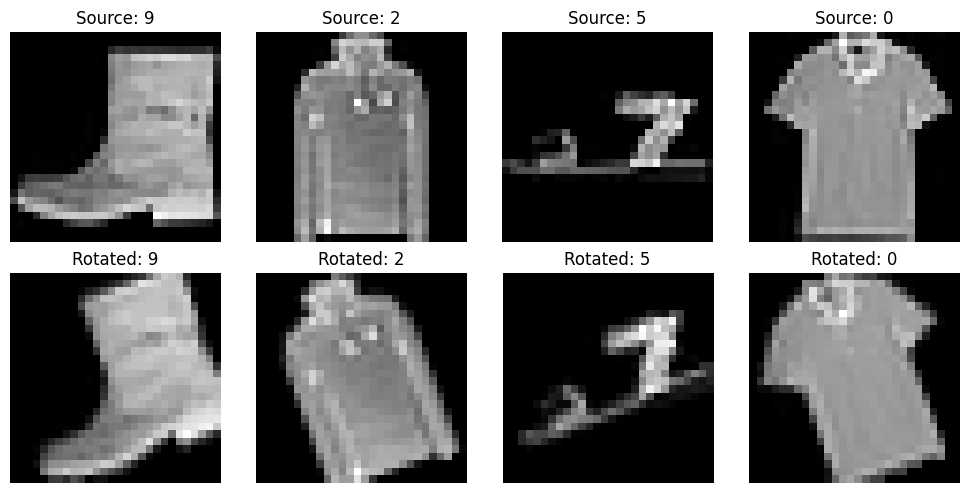

In [20]:
# Visual preprocessing check: source images beside their rotated counterparts.
def unnormalize(image: torch.Tensor) -> torch.Tensor:
    return image * CONFIG["normalization_std"][0] + CONFIG["normalization_mean"][0]


example_indices = train_indices[:4].tolist()
figure, axes = plt.subplots(2, len(example_indices), figsize=(10, 5))
for column, index in enumerate(example_indices):
    source_image, label = source_training_full[index]
    target_image, target_label = target_training_full[index]
    assert label == target_label
    axes[0, column].imshow(unnormalize(source_image).squeeze(), cmap="gray")
    axes[0, column].set_title(f"Source: {label}")
    axes[1, column].imshow(unnormalize(target_image).squeeze(), cmap="gray")
    axes[1, column].set_title(f"Rotated: {target_label}")
    axes[0, column].axis("off")
    axes[1, column].axis("off")
figure.tight_layout()
plt.show()


# 5. Baseline MLP

In [21]:
class FashionMLP(nn.Module):
    def __init__(self) -> None:
        super().__init__()
        self.fc1 = nn.Linear(28 * 28, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 10)

    def forward(self, inputs: torch.Tensor) -> torch.Tensor:
        flattened = torch.flatten(inputs, start_dim=1)
        hidden_1 = F.relu(self.fc1(flattened))
        hidden_2 = F.relu(self.fc2(hidden_1))
        return self.fc3(hidden_2)


In [22]:
seed_everything(CONFIG["seed"])
baseline_model_preview = FashionMLP().to(DEVICE)
print(baseline_model_preview)


FashionMLP(
  (fc1): Linear(in_features=784, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=10, bias=True)
)


In [23]:
assert tuple(baseline_model_preview.fc1.weight.shape) == (256, 784)
assert tuple(baseline_model_preview.fc2.weight.shape) == (128, 256)
assert tuple(baseline_model_preview.fc3.weight.shape) == (10, 128)

print("W1 shape:", tuple(baseline_model_preview.fc1.weight.shape))
print("W2 shape:", tuple(baseline_model_preview.fc2.weight.shape))
print("W3 shape:", tuple(baseline_model_preview.fc3.weight.shape))


W1 shape: (256, 784)
W2 shape: (128, 256)
W3 shape: (10, 128)


In [24]:
def parameter_counts(model: nn.Module) -> Dict[str, int]:
    total = sum(parameter.numel() for parameter in model.parameters())
    trainable = sum(
        parameter.numel() for parameter in model.parameters() if parameter.requires_grad
    )
    return {
        "total": int(total),
        "trainable": int(trainable),
        "frozen": int(total - trainable),
    }


In [25]:
BASELINE_PARAMETER_COUNT = 235_146
SELECTED_WEIGHT_PARAMETER_COUNT = 233_472
UNTOUCHED_PARAMETER_COUNT = 1_674

preview_counts = parameter_counts(baseline_model_preview)
assert preview_counts["total"] == BASELINE_PARAMETER_COUNT
assert 256 * 784 + 128 * 256 == SELECTED_WEIGHT_PARAMETER_COUNT
assert BASELINE_PARAMETER_COUNT - SELECTED_WEIGHT_PARAMETER_COUNT == UNTOUCHED_PARAMETER_COUNT
print(preview_counts)


{'total': 235146, 'trainable': 235146, 'frozen': 0}


## Parameter-count framework and compression thresholds

In [26]:
W1_MAX_COMPRESSIVE_RANK = (256 * 784 - 1) // (784 + 256)
W2_MAX_COMPRESSIVE_RANK = (128 * 256 - 1) // (256 + 128)
JOINT_MAX_COMPRESSIVE_SAME_RANK = (
    BASELINE_PARAMETER_COUNT - UNTOUCHED_PARAMETER_COUNT - 1
) // 1424

assert W1_MAX_COMPRESSIVE_RANK == 192
assert W2_MAX_COMPRESSIVE_RANK == 85
assert JOINT_MAX_COMPRESSIVE_SAME_RANK == 163
print(
    {
        "W1 maximum compressive rank": W1_MAX_COMPRESSIVE_RANK,
        "W2 maximum compressive rank": W2_MAX_COMPRESSIVE_RANK,
        "joint maximum compressive same rank": JOINT_MAX_COMPRESSIVE_SAME_RANK,
    }
)


{'W1 maximum compressive rank': 192, 'W2 maximum compressive rank': 85, 'joint maximum compressive same rank': 163}


# 6. Training and evaluation utilities

In [27]:
@torch.inference_mode()
def evaluate_model(
    model: nn.Module, loader: DataLoader, device: torch.device = DEVICE
) -> Dict[str, float]:
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    for inputs, targets in loader:
        inputs = inputs.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)
        logits = model(inputs)
        total_loss += F.cross_entropy(logits, targets, reduction="sum").item()
        total_correct += (logits.argmax(dim=1) == targets).sum().item()
        total_examples += targets.numel()

    return {
        "loss": total_loss / total_examples,
        "accuracy": total_correct / total_examples,
        "n": int(total_examples),
    }


In [28]:
def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    device: torch.device = DEVICE,
) -> Dict[str, float]:
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    for inputs, targets in loader:
        inputs = inputs.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        logits = model(inputs)
        loss = F.cross_entropy(logits, targets)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * targets.numel()
        total_correct += (logits.argmax(dim=1) == targets).sum().item()
        total_examples += targets.numel()

    return {
        "loss": total_loss / total_examples,
        "accuracy": total_correct / total_examples,
        "n": int(total_examples),
    }


In [29]:
def clone_state_dict(state_dict: Dict[str, torch.Tensor]) -> Dict[str, torch.Tensor]:
    return {name: tensor.detach().cpu().clone() for name, tensor in state_dict.items()}


def fit_model(
    model: nn.Module,
    train_dataset: Dataset,
    validation_loader: DataLoader,
    *,
    epochs: int,
    learning_rate: float,
    loader_seed: int,
    label: str,
) -> Tuple[nn.Module, pd.DataFrame, Dict[str, Any]]:
    trainable_parameters = [
        parameter for parameter in model.parameters() if parameter.requires_grad
    ]
    if not trainable_parameters:
        raise ValueError("The model has no trainable parameters.")

    train_loader = make_loader(
        train_dataset, shuffle=True, seed=loader_seed
    )
    optimizer = torch.optim.Adam(
        trainable_parameters,
        lr=learning_rate,
        weight_decay=CONFIG["weight_decay"],
    )

    best_validation_loss = math.inf
    best_state: Optional[Dict[str, torch.Tensor]] = None
    best_epoch = -1
    best_validation_metrics: Dict[str, float] = {}
    history_rows: List[Dict[str, Any]] = []

    for epoch in range(1, epochs + 1):
        training_metrics = train_one_epoch(model, train_loader, optimizer)
        validation_metrics = evaluate_model(model, validation_loader)
        history_rows.append(
            {
                "method": label,
                "epoch": epoch,
                "training_loss": training_metrics["loss"],
                "training_accuracy": training_metrics["accuracy"],
                "validation_loss": validation_metrics["loss"],
                "validation_accuracy": validation_metrics["accuracy"],
            }
        )

        if validation_metrics["loss"] < best_validation_loss:
            best_validation_loss = validation_metrics["loss"]
            best_state = clone_state_dict(model.state_dict())
            best_epoch = epoch
            best_validation_metrics = validation_metrics.copy()

        print(
            f"{label} | epoch {epoch:02d}/{epochs} | "
            f"train loss {training_metrics['loss']:.4f} | "
            f"val loss {validation_metrics['loss']:.4f} | "
            f"val acc {100 * validation_metrics['accuracy']:.2f}%"
        )

    if best_state is None:
        raise RuntimeError("No best checkpoint was recorded.")
    model.load_state_dict(best_state)
    metadata = {
        "best_epoch": int(best_epoch),
        "best_validation_loss": float(best_validation_metrics["loss"]),
        "best_validation_accuracy": float(best_validation_metrics["accuracy"]),
    }
    return model, pd.DataFrame(history_rows), metadata


In [30]:
def save_full_checkpoint(
    path: Path,
    model: nn.Module,
    metadata: Dict[str, Any],
) -> None:
    payload = {
        "model_state_dict": clone_state_dict(model.state_dict()),
        "best_epoch": int(metadata["best_epoch"]),
        "best_validation_loss": float(metadata["best_validation_loss"]),
        "best_validation_accuracy": float(metadata["best_validation_accuracy"]),
        "config": copy.deepcopy(CONFIG),
        "config_signature": CONFIG_SIGNATURE,
        "seed": CONFIG["seed"],
        "trainable_parameter_count": parameter_counts(model)["trainable"],
    }
    torch.save(payload, path)


def load_checked_checkpoint(path: Path) -> Dict[str, Any]:
    payload = safe_torch_load(path)
    if payload.get("config_signature") != CONFIG_SIGNATURE:
        raise ValueError(
            f"Checkpoint {path.name} was created under a different configuration."
        )
    return payload


In [31]:
def save_figure(
    figure: plt.Figure,
    directory: Path,
    stem: str,
    *,
    dpi: int = 300,
) -> None:
    directory.mkdir(parents=True, exist_ok=True)
    figure.savefig(directory / f"{stem}.pdf", bbox_inches="tight")
    figure.savefig(directory / f"{stem}.png", dpi=dpi, bbox_inches="tight")


def plot_training_history(csv_path: Path, output_stem: str) -> None:
    history = pd.read_csv(csv_path)

    loss_figure, loss_axis = plt.subplots(figsize=(7, 4.5))
    loss_axis.plot(history["epoch"], history["training_loss"], label="Training")
    loss_axis.plot(history["epoch"], history["validation_loss"], label="Validation")
    loss_axis.set_xlabel("Epoch")
    loss_axis.set_ylabel("Cross-entropy loss")
    loss_axis.set_title(f"{output_stem.replace('_', ' ').title()} — loss")
    loss_axis.legend()
    loss_figure.tight_layout()
    save_figure(loss_figure, SOURCE_FIGURE_DIR, f"{output_stem}_loss")
    plt.show()

    accuracy_figure, accuracy_axis = plt.subplots(figsize=(7, 4.5))
    accuracy_axis.plot(
        history["epoch"], 100 * history["training_accuracy"], label="Training"
    )
    accuracy_axis.plot(
        history["epoch"], 100 * history["validation_accuracy"], label="Validation"
    )
    accuracy_axis.set_xlabel("Epoch")
    accuracy_axis.set_ylabel("Accuracy (%)")
    accuracy_axis.set_title(f"{output_stem.replace('_', ' ').title()} — accuracy")
    accuracy_axis.legend()
    accuracy_figure.tight_layout()
    save_figure(accuracy_figure, SOURCE_FIGURE_DIR, f"{output_stem}_accuracy")
    plt.show()


# 7. Train the source baseline

In [32]:
seed_everything(CONFIG["seed"])
source_model = FashionMLP().to(DEVICE)
assert parameter_counts(source_model)["total"] == BASELINE_PARAMETER_COUNT


In [33]:
source_checkpoint_path = CHECKPOINT_DIR / "source_baseline.pt"
source_history_path = RESULTS_DIR / "source_training_history.csv"

can_reuse_source = (
    CONFIG["reuse_cached_checkpoints"]
    and source_checkpoint_path.exists()
    and source_history_path.exists()
)

if can_reuse_source:
    source_payload = load_checked_checkpoint(source_checkpoint_path)
    source_model.load_state_dict(source_payload["model_state_dict"])
    source_metadata = {
        "best_epoch": int(source_payload["best_epoch"]),
        "best_validation_loss": float(source_payload["best_validation_loss"]),
        "best_validation_accuracy": float(source_payload["best_validation_accuracy"]),
    }
    source_history = pd.read_csv(source_history_path)
    print("Loaded compatible cached source checkpoint.")
else:
    seed_everything(CONFIG["seed"])
    source_model = FashionMLP().to(DEVICE)
    source_model, source_history, source_metadata = fit_model(
        source_model,
        source_train_dataset,
        source_validation_loader,
        epochs=CONFIG["source_epochs"],
        learning_rate=CONFIG["source_learning_rate"],
        loader_seed=CONFIG["loader_seed"],
        label="source_baseline",
    )
    save_full_checkpoint(source_checkpoint_path, source_model, source_metadata)


source_baseline | epoch 01/20 | train loss 0.5333 | val loss 0.4058 | val acc 85.43%
source_baseline | epoch 02/20 | train loss 0.3779 | val loss 0.3799 | val acc 86.38%
source_baseline | epoch 03/20 | train loss 0.3413 | val loss 0.3514 | val acc 87.25%
source_baseline | epoch 04/20 | train loss 0.3110 | val loss 0.3289 | val acc 88.32%
source_baseline | epoch 05/20 | train loss 0.2936 | val loss 0.3293 | val acc 88.23%
source_baseline | epoch 06/20 | train loss 0.2752 | val loss 0.3406 | val acc 87.40%
source_baseline | epoch 07/20 | train loss 0.2607 | val loss 0.3348 | val acc 87.72%
source_baseline | epoch 08/20 | train loss 0.2463 | val loss 0.3085 | val acc 89.25%
source_baseline | epoch 09/20 | train loss 0.2368 | val loss 0.2995 | val acc 89.22%
source_baseline | epoch 10/20 | train loss 0.2259 | val loss 0.3095 | val acc 88.90%
source_baseline | epoch 11/20 | train loss 0.2157 | val loss 0.3131 | val acc 89.12%
source_baseline | epoch 12/20 | train loss 0.2071 | val loss 0.31

In [34]:
source_history.to_csv(source_history_path, index=False)
source_history.tail()


,method,epoch,training_loss,training_accuracy,validation_loss,validation_accuracy
15,source_baseline,16,0.170719,0.935759,0.321959,0.893833
16,source_baseline,17,0.164440,0.938056,0.326679,0.892667
17,source_baseline,18,0.157770,0.939815,0.349047,0.889167
18,source_baseline,19,0.148217,0.943722,0.349750,0.889500
19,source_baseline,20,0.140952,0.946333,0.362839,0.892667


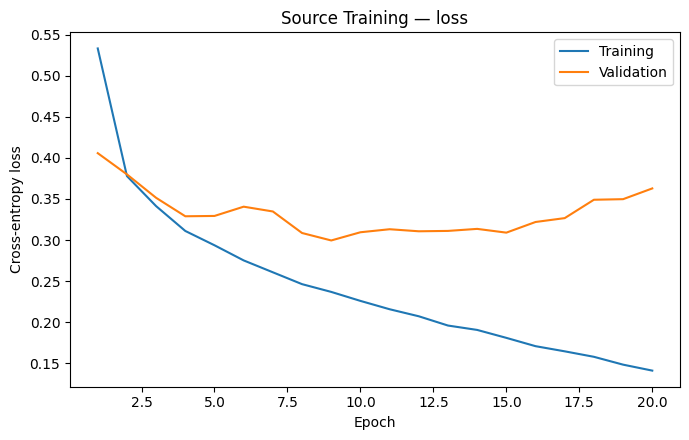

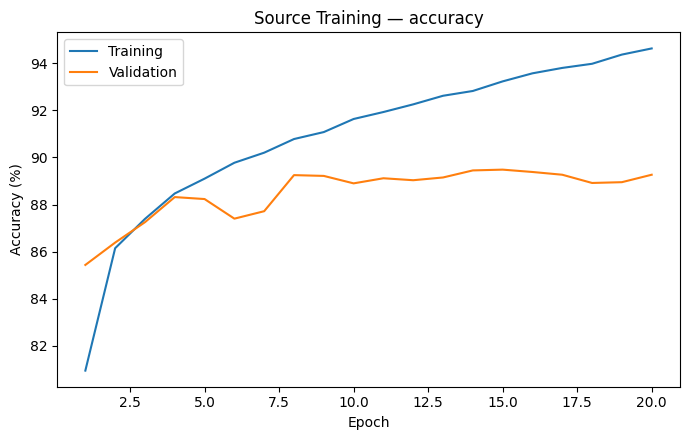

In [35]:
plot_training_history(source_history_path, "source_training")


In [36]:
# Reload from disk before beginning either experimental branch.
source_payload = load_checked_checkpoint(source_checkpoint_path)
source_model = FashionMLP().to(DEVICE)
source_model.load_state_dict(source_payload["model_state_dict"])
source_model.eval()

W0_STATE = clone_state_dict(source_model.state_dict())


In [37]:
source_validation_metrics = evaluate_model(source_model, source_validation_loader)
source_validation_metrics


{'loss': 0.29946548557281494, 'accuracy': 0.8921666666666667, 'n': 6000}

In [38]:
source_test_metrics = evaluate_model(source_model, source_test_loader)
source_test_metrics


{'loss': 0.32596326615810395, 'accuracy': 0.8838, 'n': 10000}

In [39]:
baseline_metrics = {
    "source_validation_accuracy": source_validation_metrics["accuracy"],
    "source_validation_loss": source_validation_metrics["loss"],
    "source_test_accuracy": source_test_metrics["accuracy"],
    "source_test_loss": source_test_metrics["loss"],
    "total_parameter_count": parameter_counts(source_model)["total"],
    "best_epoch": int(source_payload["best_epoch"]),
    "config_signature": CONFIG_SIGNATURE,
}

with (RESULTS_DIR / "baseline_metrics.json").open("w", encoding="utf-8") as handle:
    json.dump(baseline_metrics, handle, indent=2)

print(json.dumps(baseline_metrics, indent=2))


{
  "source_validation_accuracy": 0.8921666666666667,
  "source_validation_loss": 0.29946548557281494,
  "source_test_accuracy": 0.8838,
  "source_test_loss": 0.32596326615810395,
  "total_parameter_count": 235146,
  "best_epoch": 9,
  "config_signature": "27036506a35f2930"
}


In [40]:
def state_dict_digest(state_dict: Dict[str, torch.Tensor]) -> str:
    digest = hashlib.sha256()
    for name in sorted(state_dict):
        digest.update(name.encode("utf-8"))
        digest.update(state_dict[name].detach().cpu().contiguous().numpy().tobytes())
    return digest.hexdigest()


W0_DIGEST = state_dict_digest(W0_STATE)
fresh_source_model = FashionMLP().to(DEVICE)
fresh_source_model.load_state_dict(load_checked_checkpoint(source_checkpoint_path)["model_state_dict"])
fresh_validation_metrics = evaluate_model(fresh_source_model, source_validation_loader)
fresh_test_metrics = evaluate_model(fresh_source_model, source_test_loader)

assert fresh_validation_metrics == source_validation_metrics
assert fresh_test_metrics == source_test_metrics
assert state_dict_digest(clone_state_dict(fresh_source_model.state_dict())) == W0_DIGEST
print("Baseline checkpoint consistency check passed.")


Baseline checkpoint consistency check passed.


# Part I—Truncated-SVD compression of the baseline weights

# 8. Extract and analyze the baseline matrices

In [41]:
W1_BASE_FLOAT32 = W0_STATE["fc1.weight"].clone()
W2_BASE_FLOAT32 = W0_STATE["fc2.weight"].clone()

assert tuple(W1_BASE_FLOAT32.shape) == (256, 784)
assert tuple(W2_BASE_FLOAT32.shape) == (128, 256)


In [42]:
W1_BASE = W1_BASE_FLOAT32.to(torch.float64)
W2_BASE = W2_BASE_FLOAT32.to(torch.float64)
assert W1_BASE.dtype == torch.float64
assert W2_BASE.dtype == torch.float64


In [43]:
def reduced_svd(matrix: torch.Tensor) -> Dict[str, torch.Tensor]:
    matrix = matrix.detach().cpu().to(torch.float64)
    left, singular_values, right_transpose = torch.linalg.svd(
        matrix, full_matrices=False
    )
    return {"U": left, "S": singular_values, "Vh": right_transpose}


In [44]:
BASELINE_SVDS = {
    "W1": reduced_svd(W1_BASE),
    "W2": reduced_svd(W2_BASE),
}

assert len(BASELINE_SVDS["W1"]["S"]) == 256
assert len(BASELINE_SVDS["W2"]["S"]) == 128


In [45]:
def singular_value_table(layer: str, svd: Dict[str, torch.Tensor]) -> pd.DataFrame:
    singular_values = svd["S"]
    squared = singular_values.square()
    total_energy = squared.sum()
    cumulative = torch.cumsum(squared, dim=0) / total_energy
    return pd.DataFrame(
        {
            "layer": layer,
            "singular_value_index": np.arange(1, len(singular_values) + 1),
            "singular_value": singular_values.numpy(),
            "normalized_singular_value": (singular_values / singular_values[0]).numpy(),
            "squared_singular_value": squared.numpy(),
            "energy_fraction": (squared / total_energy).numpy(),
            "cumulative_retained_energy": cumulative.numpy(),
        }
    )


baseline_singular_values = pd.concat(
    [singular_value_table(layer, svd) for layer, svd in BASELINE_SVDS.items()],
    ignore_index=True,
)
baseline_singular_values.to_csv(
    RESULTS_DIR / "baseline_weight_singular_values.csv", index=False
)
baseline_singular_values.head()


,layer,singular_value_index,singular_value,normalized_singular_value,squared_singular_value,energy_fraction,cumulative_retained_energy
0,W1,1,7.208174,1.000000,51.957772,0.067694,0.067694
1,W1,2,6.640355,0.921226,44.094313,0.057449,0.125144
2,W1,3,6.274190,0.870427,39.365461,0.051288,0.176432
3,W1,4,6.067603,0.841767,36.815806,0.047966,0.224398
4,W1,5,5.853134,0.812013,34.259183,0.044635,0.269034


In [46]:
def smallest_rank_for_energy(
    singular_values: torch.Tensor, threshold: float
) -> int:
    cumulative = torch.cumsum(singular_values.square(), dim=0)
    cumulative = cumulative / cumulative[-1]
    threshold_tensor = torch.tensor(threshold, dtype=cumulative.dtype)
    return int(torch.searchsorted(cumulative, threshold_tensor).item() + 1)


baseline_energy_rows: List[Dict[str, Any]] = []
for layer, svd in BASELINE_SVDS.items():
    for threshold in CONFIG["energy_thresholds"]:
        baseline_energy_rows.append(
            {
                "layer": layer,
                "energy_threshold": threshold,
                "minimum_rank": smallest_rank_for_energy(svd["S"], threshold),
            }
        )

baseline_energy_thresholds = pd.DataFrame(baseline_energy_rows)
baseline_energy_thresholds


,layer,energy_threshold,minimum_rank
0,W1,0.90,82
1,W1,0.95,132
2,W1,0.99,212
3,W2,0.90,61
4,W2,0.95,81
5,W2,0.99,110


In [47]:
baseline_energy_thresholds.to_csv(
    RESULTS_DIR / "baseline_weight_energy_thresholds.csv", index=False
)


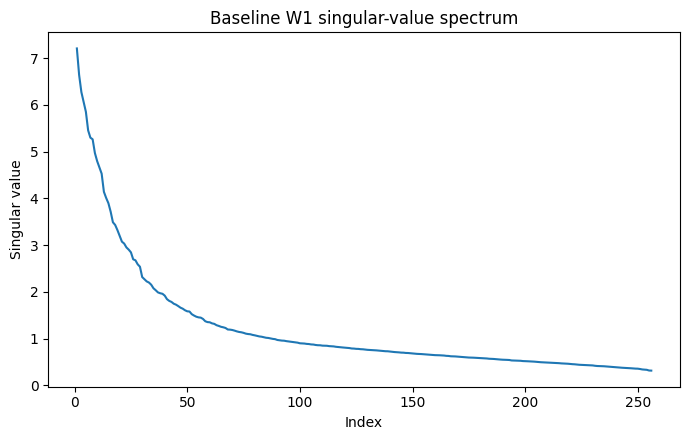

In [48]:
# Separate singular-value spectrum for W1.
singular_data = pd.read_csv(RESULTS_DIR / "baseline_weight_singular_values.csv")
w1_data = singular_data[singular_data["layer"] == "W1"]
figure, axis = plt.subplots(figsize=(7, 4.5))
axis.plot(w1_data["singular_value_index"], w1_data["singular_value"])
axis.set_xlabel("Index")
axis.set_ylabel("Singular value")
axis.set_title("Baseline W1 singular-value spectrum")
figure.tight_layout()
save_figure(figure, SOURCE_FIGURE_DIR, "w1_singular_values")
plt.show()


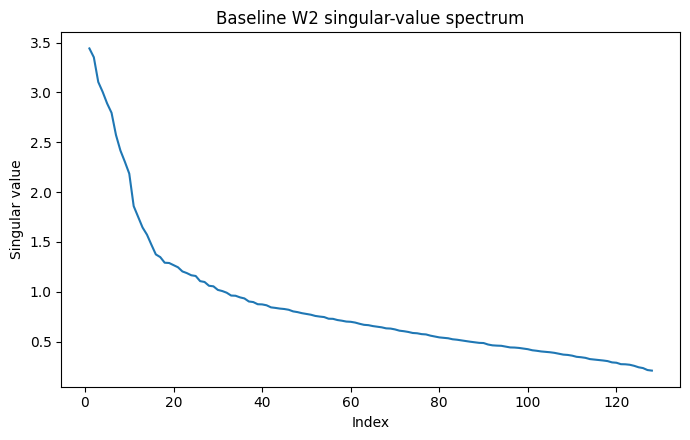

In [49]:
# Separate singular-value spectrum for W2.
singular_data = pd.read_csv(RESULTS_DIR / "baseline_weight_singular_values.csv")
w2_data = singular_data[singular_data["layer"] == "W2"]
figure, axis = plt.subplots(figsize=(7, 4.5))
axis.plot(w2_data["singular_value_index"], w2_data["singular_value"])
axis.set_xlabel("Index")
axis.set_ylabel("Singular value")
axis.set_title("Baseline W2 singular-value spectrum")
figure.tight_layout()
save_figure(figure, SOURCE_FIGURE_DIR, "w2_singular_values")
plt.show()


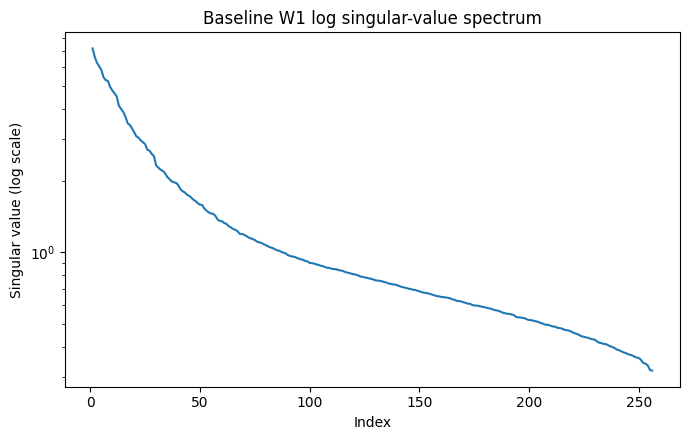

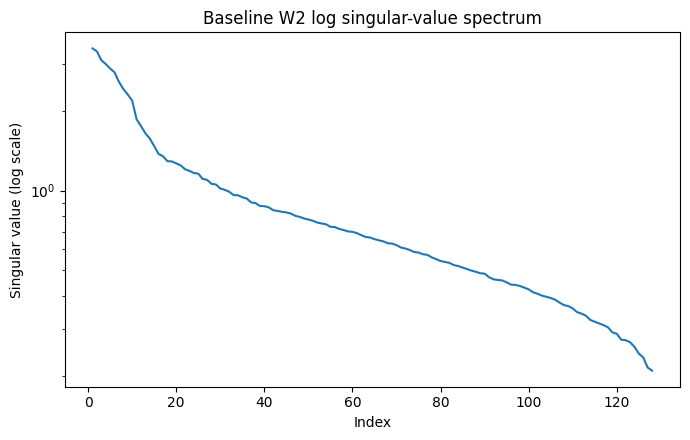

In [50]:
# Log-scale spectra.
singular_data = pd.read_csv(RESULTS_DIR / "baseline_weight_singular_values.csv")
for layer in ("W1", "W2"):
    layer_data = singular_data[singular_data["layer"] == layer]
    figure, axis = plt.subplots(figsize=(7, 4.5))
    axis.semilogy(layer_data["singular_value_index"], layer_data["singular_value"])
    axis.set_xlabel("Index")
    axis.set_ylabel("Singular value (log scale)")
    axis.set_title(f"Baseline {layer} log singular-value spectrum")
    figure.tight_layout()
    save_figure(figure, SOURCE_FIGURE_DIR, f"{layer.lower()}_singular_values_log")
    plt.show()


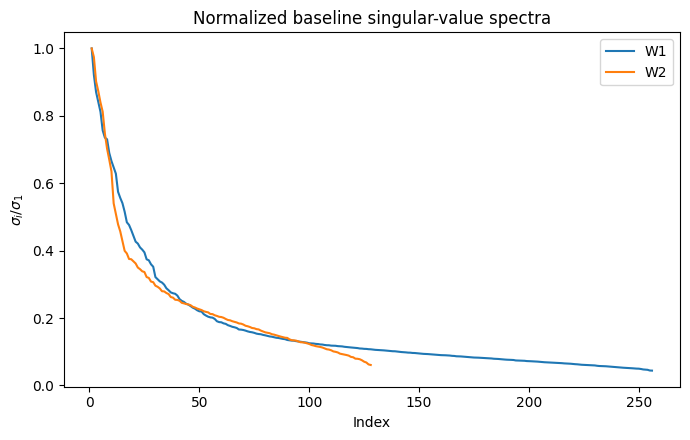

In [51]:
# Normalized spectra place differently scaled layers on a comparable vertical axis.
singular_data = pd.read_csv(RESULTS_DIR / "baseline_weight_singular_values.csv")
figure, axis = plt.subplots(figsize=(7, 4.5))
for layer in ("W1", "W2"):
    layer_data = singular_data[singular_data["layer"] == layer]
    axis.plot(
        layer_data["singular_value_index"],
        layer_data["normalized_singular_value"],
        label=layer,
    )
axis.set_xlabel("Index")
axis.set_ylabel(r"$\sigma_i / \sigma_1$")
axis.set_title("Normalized baseline singular-value spectra")
axis.legend()
figure.tight_layout()
save_figure(figure, SOURCE_FIGURE_DIR, "normalized_singular_values")
plt.show()


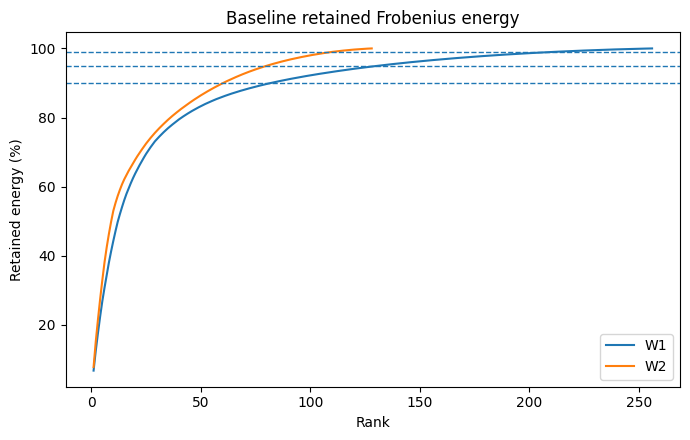

In [52]:
# Cumulative retained Frobenius energy.
singular_data = pd.read_csv(RESULTS_DIR / "baseline_weight_singular_values.csv")
figure, axis = plt.subplots(figsize=(7, 4.5))
for layer in ("W1", "W2"):
    layer_data = singular_data[singular_data["layer"] == layer]
    axis.plot(
        layer_data["singular_value_index"],
        100 * layer_data["cumulative_retained_energy"],
        label=layer,
    )
for threshold in CONFIG["energy_thresholds"]:
    axis.axhline(100 * threshold, linestyle="--", linewidth=1)
axis.set_xlabel("Rank")
axis.set_ylabel("Retained energy (%)")
axis.set_title("Baseline retained Frobenius energy")
axis.legend()
figure.tight_layout()
save_figure(figure, SOURCE_FIGURE_DIR, "retained_energy")
plt.show()


# 9. Factorized replacement for Part I

In [53]:
class FactorizedLinear(nn.Module):
    def __init__(
        self,
        first_factor: torch.Tensor,
        second_factor: torch.Tensor,
        bias: Optional[torch.Tensor],
    ) -> None:
        super().__init__()
        rank, in_features = first_factor.shape
        out_features, second_rank = second_factor.shape
        if rank != second_rank:
            raise ValueError("The factor inner dimensions do not match.")

        self.first = nn.Linear(in_features, rank, bias=False)
        self.second = nn.Linear(rank, out_features, bias=bias is not None)
        with torch.no_grad():
            self.first.weight.copy_(first_factor)
            self.second.weight.copy_(second_factor)
            if bias is not None:
                self.second.bias.copy_(bias)

        for parameter in self.parameters():
            parameter.requires_grad = False

    def forward(self, inputs: torch.Tensor) -> torch.Tensor:
        return self.second(self.first(inputs))


In [54]:
def svd_to_factors(
    svd: Dict[str, torch.Tensor], rank: int, dtype: torch.dtype = torch.float32
) -> Tuple[torch.Tensor, torch.Tensor]:
    maximum_rank = len(svd["S"])
    if not 1 <= rank <= maximum_rank:
        raise ValueError(f"rank must lie in [1, {maximum_rank}]")

    square_root_values = torch.sqrt(svd["S"][:rank])
    first_factor = square_root_values[:, None] * svd["Vh"][:rank, :]
    second_factor = svd["U"][:, :rank] * square_root_values[None, :]
    return first_factor.to(dtype), second_factor.to(dtype)


In [55]:
def build_factorized_model(
    rank_w1: Optional[int], rank_w2: Optional[int]
) -> FashionMLP:
    model = FashionMLP()
    model.load_state_dict(W0_STATE)

    if rank_w1 is not None:
        first, second = svd_to_factors(BASELINE_SVDS["W1"], rank_w1)
        model.fc1 = FactorizedLinear(first, second, W0_STATE["fc1.bias"])
    if rank_w2 is not None:
        first, second = svd_to_factors(BASELINE_SVDS["W2"], rank_w2)
        model.fc2 = FactorizedLinear(first, second, W0_STATE["fc2.bias"])

    for parameter in model.parameters():
        parameter.requires_grad = False
    return model.to(DEVICE)


In [57]:
# A factorized layer must match direct multiplication by the same W_r.
rank_for_check=min(16,len(BASELINE_SVDS["W1"]["S"]))
first_check,second_check=svd_to_factors(BASELINE_SVDS["W1"],rank_for_check)
factorized_check=FactorizedLinear(first_check,second_check,W0_STATE["fc1.bias"]).eval()
random_inputs=torch.randn(32,784)
truncated_weight=second_check@first_check
direct_outputs=F.linear(random_inputs,truncated_weight,W0_STATE["fc1.bias"])
factor_outputs=factorized_check(random_inputs)
# The materialized and sequential GEMM paths differ slightly from float32 rounding.
assert torch.allclose(direct_outputs,factor_outputs,atol=5e-6,rtol=1e-5)
print("Factorized-output check passed.")

Factorized-output check passed.


In [58]:
# Maximum-rank matrix reconstructions.
for layer, original in (("W1", W1_BASE), ("W2", W2_BASE)):
    maximum_rank = len(BASELINE_SVDS[layer]["S"])
    first, second = svd_to_factors(
        BASELINE_SVDS[layer], maximum_rank, dtype=torch.float64
    )
    reconstructed = second @ first
    relative_error = torch.linalg.matrix_norm(original - reconstructed) / torch.linalg.matrix_norm(original)
    assert relative_error.item() < 1e-12
    print(layer, "maximum-rank relative error:", relative_error.item())


W1 maximum-rank relative error: 3.041087786620229e-15
W2 maximum-rank relative error: 2.7501755741205756e-15


In [59]:
# Structural checks for bias placement and activation placement.
structure_check_model = build_factorized_model(16, 16)
assert isinstance(structure_check_model.fc1, FactorizedLinear)
assert isinstance(structure_check_model.fc2, FactorizedLinear)
assert structure_check_model.fc1.first.bias is None
assert structure_check_model.fc2.first.bias is None
assert structure_check_model.fc1.second.bias is not None
assert structure_check_model.fc2.second.bias is not None
assert not any(isinstance(module, nn.ReLU) for module in structure_check_model.fc1.modules())
assert not any(isinstance(module, nn.ReLU) for module in structure_check_model.fc2.modules())
print("Bias and activation placement checks passed.")


Bias and activation placement checks passed.


In [60]:
def expected_factorized_parameter_count(
    rank_w1: Optional[int], rank_w2: Optional[int]
) -> int:
    total = BASELINE_PARAMETER_COUNT
    if rank_w1 is not None:
        total = total - 256 * 784 + rank_w1 * (784 + 256)
    if rank_w2 is not None:
        total = total - 128 * 256 + rank_w2 * (256 + 128)
    return int(total)


for ranks in ((16, None), (None, 16), (16, 16), (256, 128)):
    model = build_factorized_model(*ranks)
    actual = parameter_counts(model)["total"]
    expected = expected_factorized_parameter_count(*ranks)
    assert actual == expected
    print(ranks, actual)


(16, None) 51082
(None, 16) 208522
(16, 16) 24458
(256, 128) 317066


# 10. Reconstruction metrics and Eckart–Young verification

In [61]:
def frobenius_metrics(
    original: torch.Tensor, approximation: torch.Tensor
) -> Dict[str, float]:
    absolute_error = torch.linalg.matrix_norm(original - approximation).item()
    original_norm = torch.linalg.matrix_norm(original).item()
    return {
        "absolute_error": absolute_error,
        "relative_error": absolute_error / original_norm,
    }


In [62]:
def theoretical_tail_error(singular_values: torch.Tensor, rank: int) -> float:
    return torch.sqrt(singular_values[rank:].square().sum()).item()


In [63]:
def retained_energy(singular_values: torch.Tensor, rank: int) -> float:
    return (
        singular_values[:rank].square().sum() / singular_values.square().sum()
    ).item()


In [64]:
def full_rank_metric_sweep(
    layer: str,
    matrix: torch.Tensor,
    svd: Dict[str, torch.Tensor],
) -> pd.DataFrame:
    residual = matrix.detach().cpu().to(torch.float64).clone()
    original_norm = torch.linalg.matrix_norm(matrix).item()
    rows: List[Dict[str, Any]] = []

    for index in range(len(svd["S"])):
        rank_one_term = svd["S"][index] * torch.outer(
            svd["U"][:, index], svd["Vh"][index, :]
        )
        residual -= rank_one_term
        rank = index + 1
        direct_error = torch.linalg.matrix_norm(residual).item()
        theory_error = theoretical_tail_error(svd["S"], rank)
        energy = retained_energy(svd["S"], rank)
        rows.append(
            {
                "layer": layer,
                "rank": rank,
                "absolute_frobenius_error": direct_error,
                "theoretical_tail_error": theory_error,
                "absolute_error_difference": abs(direct_error - theory_error),
                "relative_frobenius_error": direct_error / original_norm,
                "retained_energy": energy,
            }
        )
    return pd.DataFrame(rows)


In [65]:
baseline_rank_metrics = pd.concat(
    [
        full_rank_metric_sweep("W1", W1_BASE, BASELINE_SVDS["W1"]),
        full_rank_metric_sweep("W2", W2_BASE, BASELINE_SVDS["W2"]),
    ],
    ignore_index=True,
)
baseline_rank_metrics.head()


,layer,rank,absolute_frobenius_error,theoretical_tail_error,absolute_error_difference,relative_frobenius_error,retained_energy
0,W1,1,26.750258,26.750258,9.947598e-14,0.965560,0.067694
1,W1,2,25.912969,25.912969,7.105427e-15,0.935338,0.125144
2,W1,3,25.141928,25.141928,3.552714e-14,0.907506,0.176432
3,W1,4,24.398785,24.398785,5.684342e-14,0.880683,0.224398
4,W1,5,23.686315,23.686315,3.552714e-15,0.854966,0.269034


In [66]:
# Numerical Eckart–Young check.
for layer in ("W1", "W2"):
    layer_metrics = baseline_rank_metrics[baseline_rank_metrics["layer"] == layer]
    largest_difference = layer_metrics["absolute_error_difference"].max()
    scale = torch.linalg.matrix_norm(W1_BASE if layer == "W1" else W2_BASE).item()
    assert largest_difference <= 1e-10 * max(1.0, scale)
    print(layer, "maximum direct/theoretical difference:", largest_difference)


W1 maximum direct/theoretical difference: 9.947598300641403e-14
W2 maximum direct/theoretical difference: 3.343712600970417e-14


In [67]:
# Energy-error identity and monotonicity checks.
identity_values = (
    baseline_rank_metrics["relative_frobenius_error"] ** 2
    + baseline_rank_metrics["retained_energy"]
)
assert np.allclose(identity_values.to_numpy(), 1.0, atol=1e-10, rtol=1e-10)

for layer in ("W1", "W2"):
    layer_metrics = baseline_rank_metrics[baseline_rank_metrics["layer"] == layer]
    assert np.all(np.diff(layer_metrics["retained_energy"]) >= -1e-12)
    assert np.all(np.diff(layer_metrics["relative_frobenius_error"]) <= 1e-12)
print("Energy identity and monotonicity checks passed.")


Energy identity and monotonicity checks passed.


In [68]:
baseline_rank_metrics.to_csv(
    RESULTS_DIR / "baseline_weight_rank_metrics.csv", index=False
)


# 11. Part I classification sweeps

In [69]:
def energy_rank(layer: str, threshold: float, table: pd.DataFrame) -> int:
    row = table[
        (table["layer"] == layer)
        & np.isclose(table["energy_threshold"], threshold)
    ]
    if len(row) != 1:
        raise RuntimeError("Energy-rank lookup was not unique.")
    return int(row.iloc[0]["minimum_rank"])


if CONFIG["fast_dev_run"]:
    w1_rank_grid = sorted(set(CONFIG["w1_fixed_grid"]))
    w2_rank_grid = sorted(set(CONFIG["w2_fixed_grid"]))
    joint_rank_grid = sorted(set(CONFIG["joint_fixed_grid"]))
else:
    w1_rank_grid = sorted(
        set(CONFIG["w1_fixed_grid"])
        | {energy_rank("W1", threshold, baseline_energy_thresholds) for threshold in CONFIG["energy_thresholds"]}
    )
    w2_rank_grid = sorted(
        set(CONFIG["w2_fixed_grid"])
        | {energy_rank("W2", threshold, baseline_energy_thresholds) for threshold in CONFIG["energy_thresholds"]}
    )
    joint_rank_grid = sorted(
        set(CONFIG["joint_fixed_grid"])
        | {energy_rank("W1", threshold, baseline_energy_thresholds) for threshold in CONFIG["energy_thresholds"]}
        | {energy_rank("W2", threshold, baseline_energy_thresholds) for threshold in CONFIG["energy_thresholds"]}
    )
    joint_rank_grid = [rank for rank in joint_rank_grid if rank <= 128]

print("W1 grid:", w1_rank_grid)
print("W2 grid:", w2_rank_grid)
print("Joint same-rank grid:", joint_rank_grid)


W1 grid: [1, 2, 4, 8, 16, 32, 48, 64, 80, 82, 96, 112, 128, 132, 160, 192, 212, 224, 256]
W2 grid: [1, 2, 4, 8, 16, 32, 48, 61, 64, 80, 81, 85, 96, 110, 112, 128]
Joint same-rank grid: [1, 2, 4, 8, 16, 32, 48, 61, 64, 80, 81, 82, 85, 96, 110, 112, 128]


In [70]:
def lookup_rank_metrics(layer: str, rank: Optional[int]) -> Dict[str, float]:
    if rank is None:
        return {
            "absolute_frobenius_error": 0.0,
            "relative_frobenius_error": 0.0,
            "retained_energy": 1.0,
        }
    rows = baseline_rank_metrics[
        (baseline_rank_metrics["layer"] == layer)
        & (baseline_rank_metrics["rank"] == rank)
    ]
    if len(rows) != 1:
        raise RuntimeError(f"Missing rank metric for {layer}, rank {rank}.")
    return rows.iloc[0][
        [
            "absolute_frobenius_error",
            "relative_frobenius_error",
            "retained_energy",
        ]
    ].to_dict()


In [71]:
def evaluate_compression_configuration(
    method: str,
    rank_w1: Optional[int],
    rank_w2: Optional[int],
    configuration_tag: str,
) -> Dict[str, Any]:
    model = build_factorized_model(rank_w1, rank_w2)
    validation = evaluate_model(model, source_validation_loader)
    test = evaluate_model(model, source_test_loader)
    counts = parameter_counts(model)
    expected_count = expected_factorized_parameter_count(rank_w1, rank_w2)
    assert counts["total"] == expected_count

    w1_metrics = lookup_rank_metrics("W1", rank_w1)
    w2_metrics = lookup_rank_metrics("W2", rank_w2)
    combined_absolute_error = math.sqrt(
        w1_metrics["absolute_frobenius_error"] ** 2
        + w2_metrics["absolute_frobenius_error"] ** 2
    )
    combined_original_norm = math.sqrt(
        torch.linalg.matrix_norm(W1_BASE).item() ** 2
        + torch.linalg.matrix_norm(W2_BASE).item() ** 2
    )

    row = {
        "experiment": "part1_source_compression",
        "method": method,
        "configuration_tag": configuration_tag,
        "rank_w1": int(rank_w1 or 0),
        "rank_w2": int(rank_w2 or 0),
        "compressed_w1": bool(rank_w1 is not None),
        "compressed_w2": bool(rank_w2 is not None),
        "source_validation_loss": validation["loss"],
        "source_validation_accuracy": validation["accuracy"],
        "source_test_loss": test["loss"],
        "source_test_accuracy": test["accuracy"],
        "source_test_accuracy_drop_pp": 100 * (
            baseline_metrics["source_test_accuracy"] - test["accuracy"]
        ),
        "absolute_error_w1": w1_metrics["absolute_frobenius_error"],
        "relative_error_w1": w1_metrics["relative_frobenius_error"],
        "retained_energy_w1": w1_metrics["retained_energy"],
        "absolute_error_w2": w2_metrics["absolute_frobenius_error"],
        "relative_error_w2": w2_metrics["relative_frobenius_error"],
        "retained_energy_w2": w2_metrics["retained_energy"],
        "combined_relative_reconstruction_error": combined_absolute_error / combined_original_norm,
        "whole_model_parameters": counts["total"],
        "parameter_fraction": counts["total"] / BASELINE_PARAMETER_COUNT,
        "compression_factor": BASELINE_PARAMETER_COUNT / counts["total"],
        "seed": CONFIG["seed"],
    }
    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return row


In [72]:
compression_rows: List[Dict[str, Any]] = []
for rank in w1_rank_grid:
    compression_rows.append(
        evaluate_compression_configuration("w1_only", rank, None, "fixed_or_energy")
    )
print(f"Completed {len(w1_rank_grid)} W1-only configurations.")


Completed 19 W1-only configurations.


In [73]:
for rank in w2_rank_grid:
    compression_rows.append(
        evaluate_compression_configuration("w2_only", None, rank, "fixed_or_energy")
    )
print(f"Completed {len(w2_rank_grid)} W2-only configurations.")


Completed 16 W2-only configurations.


In [74]:
for rank in joint_rank_grid:
    compression_rows.append(
        evaluate_compression_configuration("joint_same_rank", rank, rank, "same_rank")
    )
print(f"Completed {len(joint_rank_grid)} joint same-rank configurations.")


Completed 17 joint same-rank configurations.


In [75]:
if CONFIG["fast_dev_run"]:
    print("FAST_DEV_RUN: skipped energy-matched classification evaluations.")
else:
    for threshold in CONFIG["energy_thresholds"]:
        rank_w1 = energy_rank("W1", threshold, baseline_energy_thresholds)
        rank_w2 = energy_rank("W2", threshold, baseline_energy_thresholds)
        compression_rows.append(
            evaluate_compression_configuration(
                "joint_energy_matched",
                rank_w1,
                rank_w2,
                f"energy_{int(100 * threshold)}",
            )
        )
    print("Completed energy-matched joint configurations.")


Completed energy-matched joint configurations.


In [76]:
@torch.inference_mode()
def collect_predictions(model: nn.Module, loader: DataLoader) -> torch.Tensor:
    model.eval()
    predictions: List[torch.Tensor] = []
    for inputs, _ in loader:
        predictions.append(model(inputs.to(DEVICE)).argmax(dim=1).cpu())
    return torch.cat(predictions)


if CONFIG["fast_dev_run"]:
    print("FAST_DEV_RUN: skipped the exact-pair classifier evaluation.")
else:
    exact_compression_row = evaluate_compression_configuration(
        "joint_exact", 256, 128, "exact_pair"
    )
    compression_rows.append(exact_compression_row)
    exact_factorized_model = build_factorized_model(256, 128)
    dense_predictions = collect_predictions(source_model, source_test_loader)
    exact_predictions = collect_predictions(exact_factorized_model, source_test_loader)
    assert torch.equal(dense_predictions, exact_predictions)
    print("The exact pair reproduces all baseline source-test predictions.")


The exact pair reproduces all baseline source-test predictions.


In [77]:
dense_baseline_row = {
    "experiment": "part1_source_compression",
    "method": "dense_baseline",
    "configuration_tag": "dense",
    "rank_w1": 0,
    "rank_w2": 0,
    "compressed_w1": False,
    "compressed_w2": False,
    "source_validation_loss": baseline_metrics["source_validation_loss"],
    "source_validation_accuracy": baseline_metrics["source_validation_accuracy"],
    "source_test_loss": baseline_metrics["source_test_loss"],
    "source_test_accuracy": baseline_metrics["source_test_accuracy"],
    "source_test_accuracy_drop_pp": 0.0,
    "absolute_error_w1": 0.0,
    "relative_error_w1": 0.0,
    "retained_energy_w1": 1.0,
    "absolute_error_w2": 0.0,
    "relative_error_w2": 0.0,
    "retained_energy_w2": 1.0,
    "combined_relative_reconstruction_error": 0.0,
    "whole_model_parameters": BASELINE_PARAMETER_COUNT,
    "parameter_fraction": 1.0,
    "compression_factor": 1.0,
    "seed": CONFIG["seed"],
}
compression_rows.append(dense_baseline_row)


In [78]:
compression_results = pd.DataFrame(compression_rows)
compression_results = compression_results.sort_values(
    ["method", "rank_w1", "rank_w2", "configuration_tag"]
).reset_index(drop=True)
assert not compression_results.isna().any().any()
compression_results.to_csv(RESULTS_DIR / "compression_sweep.csv", index=False)
compression_results.head()


,experiment,method,configuration_tag,rank_w1,rank_w2,compressed_w1,compressed_w2,source_validation_loss,source_validation_accuracy,source_test_loss,...,relative_error_w1,retained_energy_w1,absolute_error_w2,relative_error_w2,retained_energy_w2,combined_relative_reconstruction_error,whole_model_parameters,parameter_fraction,compression_factor,seed
0,part1_source_compression,dense_baseline,dense,0,0,False,False,0.299465,0.892167,0.325963,...,0.000000e+00,1.000000,0.000000e+00,0.000000e+00,1.000000,0.000000e+00,235146,1.000000,1.000000,42
1,part1_source_compression,joint_energy_matched,energy_90,82,61,True,True,0.300600,0.893833,0.328337,...,3.160448e-01,0.900116,3.844194e+00,3.118880e-01,0.902726,3.153618e-01,110378,0.469402,2.130370,42
2,part1_source_compression,joint_energy_matched,energy_95,132,81,True,True,0.300017,0.892167,0.326849,...,2.220657e-01,0.950687,2.708169e+00,2.197198e-01,0.951723,2.216798e-01,170058,0.723202,1.382740,42
3,part1_source_compression,joint_energy_matched,energy_99,212,110,True,True,0.299170,0.892000,0.325574,...,9.845187e-02,0.990307,1.228507e+00,9.967154e-02,0.990066,9.865444e-02,264394,1.124382,0.889377,42
4,part1_source_compression,joint_exact,exact_pair,256,128,True,True,0.299465,0.892167,0.325963,...,2.972782e-15,1.000000,3.343713e-14,2.712829e-15,1.000000,2.931421e-15,317066,1.348379,0.741631,42


# 12. Part I figures and tables

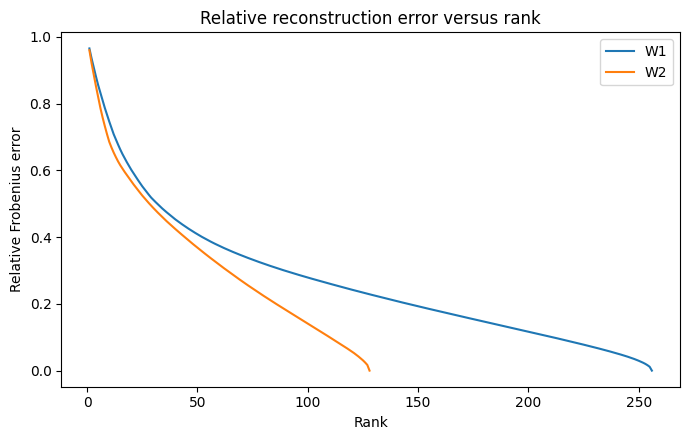

In [79]:
rank_data = pd.read_csv(RESULTS_DIR / "baseline_weight_rank_metrics.csv")
figure, axis = plt.subplots(figsize=(7, 4.5))
for layer in ("W1", "W2"):
    layer_data = rank_data[rank_data["layer"] == layer]
    axis.plot(
        layer_data["rank"],
        layer_data["relative_frobenius_error"],
        label=layer,
    )
axis.set_xlabel("Rank")
axis.set_ylabel("Relative Frobenius error")
axis.set_title("Relative reconstruction error versus rank")
axis.legend()
figure.tight_layout()
save_figure(figure, SOURCE_FIGURE_DIR, "relative_error_vs_rank")
plt.show()


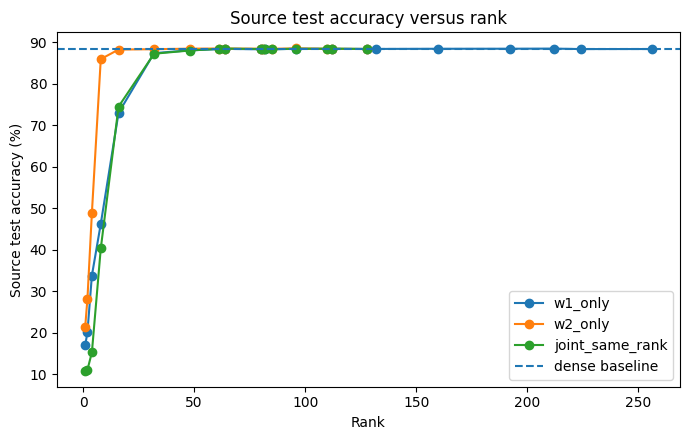

In [80]:
plot_data = pd.read_csv(RESULTS_DIR / "compression_sweep.csv")
figure, axis = plt.subplots(figsize=(7, 4.5))
for method in ("w1_only", "w2_only", "joint_same_rank"):
    method_data = plot_data[plot_data["method"] == method].sort_values(
        ["rank_w1", "rank_w2"]
    )
    rank_values = np.maximum(method_data["rank_w1"], method_data["rank_w2"])
    axis.plot(rank_values, 100 * method_data["source_test_accuracy"], marker="o", label=method)
axis.axhline(100 * baseline_metrics["source_test_accuracy"], linestyle="--", label="dense baseline")
axis.set_xlabel("Rank")
axis.set_ylabel("Source test accuracy (%)")
axis.set_title("Source test accuracy versus rank")
axis.legend()
figure.tight_layout()
save_figure(figure, SOURCE_FIGURE_DIR, "source_accuracy_vs_rank")
plt.show()


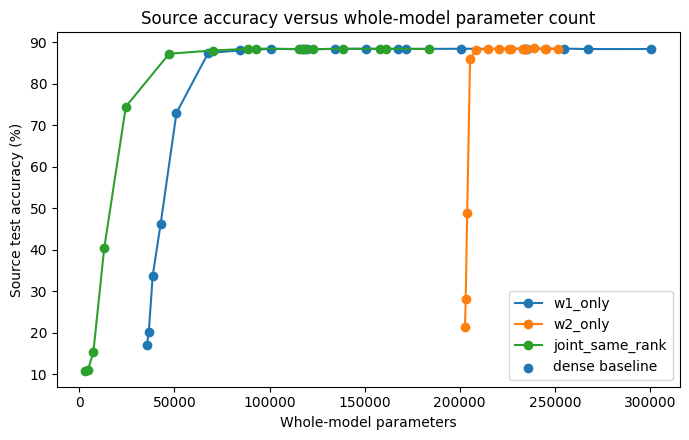

In [81]:
plot_data = pd.read_csv(RESULTS_DIR / "compression_sweep.csv")
figure, axis = plt.subplots(figsize=(7, 4.5))
for method in ("w1_only", "w2_only", "joint_same_rank"):
    method_data = plot_data[plot_data["method"] == method].sort_values("whole_model_parameters")
    axis.plot(
        method_data["whole_model_parameters"],
        100 * method_data["source_test_accuracy"],
        marker="o",
        label=method,
    )
axis.scatter([BASELINE_PARAMETER_COUNT], [100 * baseline_metrics["source_test_accuracy"]], label="dense baseline")
axis.set_xlabel("Whole-model parameters")
axis.set_ylabel("Source test accuracy (%)")
axis.set_title("Source accuracy versus whole-model parameter count")
axis.legend()
figure.tight_layout()
save_figure(figure, SOURCE_FIGURE_DIR, "source_accuracy_vs_parameters")
plt.show()


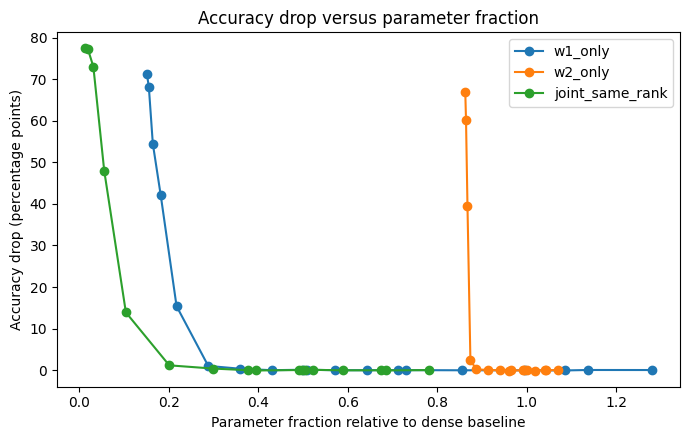

In [82]:
plot_data = pd.read_csv(RESULTS_DIR / "compression_sweep.csv")
figure, axis = plt.subplots(figsize=(7, 4.5))
for method in ("w1_only", "w2_only", "joint_same_rank"):
    method_data = plot_data[plot_data["method"] == method].sort_values("parameter_fraction")
    axis.plot(
        method_data["parameter_fraction"],
        method_data["source_test_accuracy_drop_pp"],
        marker="o",
        label=method,
    )
axis.set_xlabel("Parameter fraction relative to dense baseline")
axis.set_ylabel("Accuracy drop (percentage points)")
axis.set_title("Accuracy drop versus parameter fraction")
axis.legend()
figure.tight_layout()
save_figure(figure, SOURCE_FIGURE_DIR, "accuracy_drop_vs_parameter_fraction")
plt.show()


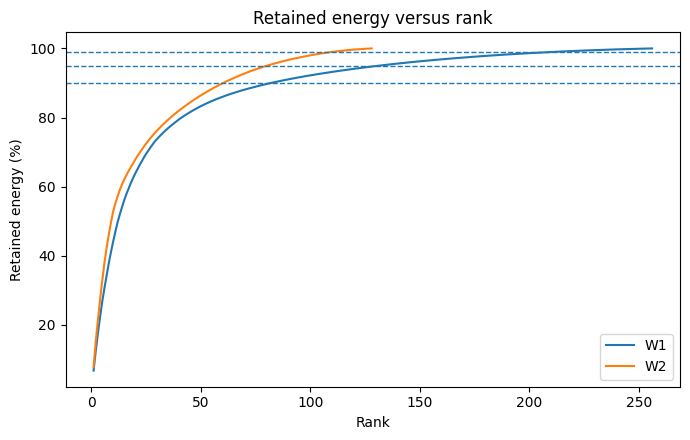

In [83]:
rank_data = pd.read_csv(RESULTS_DIR / "baseline_weight_rank_metrics.csv")
figure, axis = plt.subplots(figsize=(7, 4.5))
for layer in ("W1", "W2"):
    layer_data = rank_data[rank_data["layer"] == layer]
    axis.plot(layer_data["rank"], 100 * layer_data["retained_energy"], label=layer)
for threshold in CONFIG["energy_thresholds"]:
    axis.axhline(100 * threshold, linestyle="--", linewidth=1)
axis.set_xlabel("Rank")
axis.set_ylabel("Retained energy (%)")
axis.set_title("Retained energy versus rank")
axis.legend()
figure.tight_layout()
save_figure(figure, SOURCE_FIGURE_DIR, "retained_energy_vs_rank")
plt.show()


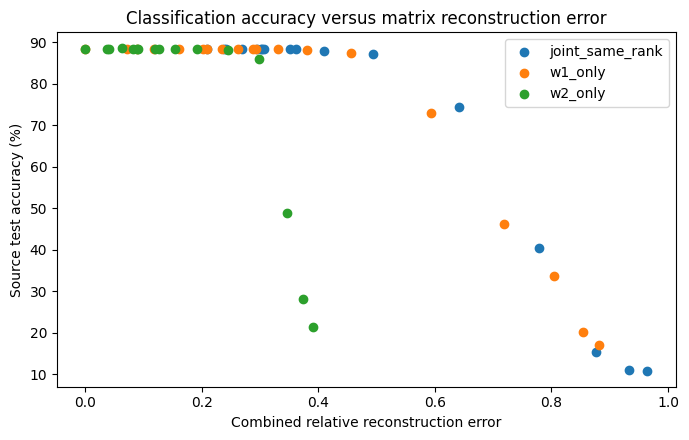

In [84]:
plot_data = pd.read_csv(RESULTS_DIR / "compression_sweep.csv")
plot_data = plot_data[plot_data["method"].isin(["w1_only", "w2_only", "joint_same_rank"])]
figure, axis = plt.subplots(figsize=(7, 4.5))
for method, method_data in plot_data.groupby("method"):
    axis.scatter(
        method_data["combined_relative_reconstruction_error"],
        100 * method_data["source_test_accuracy"],
        label=method,
    )
axis.set_xlabel("Combined relative reconstruction error")
axis.set_ylabel("Source test accuracy (%)")
axis.set_title("Classification accuracy versus matrix reconstruction error")
axis.legend()
figure.tight_layout()
save_figure(figure, SOURCE_FIGURE_DIR, "accuracy_vs_relative_reconstruction_error")
plt.show()


In [85]:
baseline_summary_table = pd.DataFrame([baseline_metrics])
energy_rank_table = pd.read_csv(RESULTS_DIR / "baseline_weight_energy_thresholds.csv")
compression_summary_table = pd.read_csv(RESULTS_DIR / "compression_sweep.csv")

display(baseline_summary_table)
display(energy_rank_table)
display(compression_summary_table.head(20))


,source_validation_accuracy,source_validation_loss,source_test_accuracy,source_test_loss,total_parameter_count,best_epoch,config_signature
0,0.892167,0.299465,0.8838,0.325963,235146,9,27036506a35f2930


,layer,energy_threshold,minimum_rank
0,W1,0.90,82
1,W1,0.95,132
2,W1,0.99,212
3,W2,0.90,61
4,W2,0.95,81
5,W2,0.99,110


,experiment,method,configuration_tag,rank_w1,rank_w2,compressed_w1,compressed_w2,source_validation_loss,source_validation_accuracy,source_test_loss,...,relative_error_w1,retained_energy_w1,absolute_error_w2,relative_error_w2,retained_energy_w2,combined_relative_reconstruction_error,whole_model_parameters,parameter_fraction,compression_factor,seed
0,part1_source_compression,dense_baseline,dense,0,0,False,False,0.299465,0.892167,0.325963,...,0.000000e+00,1.000000,0.000000e+00,0.000000e+00,1.000000,0.000000e+00,235146,1.000000,1.000000,42
1,part1_source_compression,joint_energy_matched,energy_90,82,61,True,True,0.300600,0.893833,0.328337,...,3.160448e-01,0.900116,3.844194e+00,3.118880e-01,0.902726,3.153618e-01,110378,0.469402,2.130370,42
2,part1_source_compression,joint_energy_matched,energy_95,132,81,True,True,0.300017,0.892167,0.326849,...,2.220657e-01,0.950687,2.708169e+00,2.197198e-01,0.951723,2.216798e-01,170058,0.723202,1.382740,42
3,part1_source_compression,joint_energy_matched,energy_99,212,110,True,True,0.299170,0.892000,0.325574,...,9.845187e-02,0.990307,1.228507e+00,9.967154e-02,0.990066,9.865444e-02,264394,1.124382,0.889377,42
4,part1_source_compression,joint_exact,exact_pair,256,128,True,True,0.299465,0.892167,0.325963,...,2.972782e-15,1.000000,3.343713e-14,2.712829e-15,1.000000,2.931421e-15,317066,1.348379,0.741631,42
5,part1_source_compression,joint_same_rank,same_rank,1,1,True,True,2.310062,0.110500,2.313337,...,9.655597e-01,0.067694,1.183527e+01,9.602218e-01,0.077974,9.646798e-01,3098,0.013175,75.902518,42
6,part1_source_compression,joint_same_rank,same_rank,2,2,True,True,3.750228,0.112333,3.728754,...,9.353375e-01,0.125144,1.135032e+01,9.208771e-01,0.151985,9.329637e-01,4522,0.019231,52.000442,42
7,part1_source_compression,joint_same_rank,same_rank,4,4,True,True,4.148245,0.151000,4.161026,...,8.806825e-01,0.224398,1.049555e+01,8.515278e-01,0.274900,8.759323e-01,7370,0.031342,31.905834,42
8,part1_source_compression,joint_same_rank,same_rank,8,8,True,True,2.550574,0.400167,2.556869,...,7.870655e-01,0.380528,9.028806e+00,7.325272e-01,0.463404,7.783179e-01,13066,0.055565,17.996786,42
9,part1_source_compression,joint_same_rank,same_rank,16,16,True,True,0.706131,0.754500,0.734552,...,6.488809e-01,0.578954,7.460428e+00,6.052811e-01,0.633635,6.418813e-01,24458,0.104012,9.614278,42


In [86]:
# Select efficient configurations using validation accuracy only, then report test metrics.
selection_pool = compression_results[
    compression_results["method"] != "dense_baseline"
].copy()
selection_rows: List[Dict[str, Any]] = []
for tolerance_pp in (1.0, 2.0):
    minimum_allowed_accuracy = (
        baseline_metrics["source_validation_accuracy"] - tolerance_pp / 100.0
    )
    eligible = selection_pool[
        selection_pool["source_validation_accuracy"] >= minimum_allowed_accuracy
    ].sort_values(["parameter_fraction", "source_validation_loss"])
    if eligible.empty:
        selected = selection_pool.sort_values(
            ["source_validation_accuracy", "parameter_fraction"],
            ascending=[False, True],
        ).iloc[0].to_dict()
        selected["selection_status"] = "none_met_tolerance_closest_shown"
    else:
        selected = eligible.iloc[0].to_dict()
        selected["selection_status"] = "met_tolerance"
    selected["validation_tolerance_pp"] = tolerance_pp
    selection_rows.append(selected)

validation_selected_compression = pd.DataFrame(selection_rows)
assert not validation_selected_compression.isna().any().any()
validation_selected_compression.to_csv(
    RESULTS_DIR / "best_validation_selected_compression.csv", index=False
)
validation_selected_compression


,experiment,method,configuration_tag,rank_w1,rank_w2,compressed_w1,compressed_w2,source_validation_loss,source_validation_accuracy,source_test_loss,...,absolute_error_w2,relative_error_w2,retained_energy_w2,combined_relative_reconstruction_error,whole_model_parameters,parameter_fraction,compression_factor,seed,selection_status,validation_tolerance_pp
0,part1_source_compression,joint_same_rank,same_rank,48,48,True,True,0.308320,0.889667,0.338052,...,4.672307,0.379075,0.856302,0.410691,70026,0.297798,3.357981,42,met_tolerance,1.0
1,part1_source_compression,joint_same_rank,same_rank,32,32,True,True,0.334451,0.879667,0.362365,...,5.837963,0.473647,0.775659,0.494630,47242,0.200905,4.977478,42,met_tolerance,2.0


# Part II—Full fine-tuning, update SVD, and LoRA

# 13. Establish the rotated target task

In [87]:
target_base_model = FashionMLP().to(DEVICE)
target_base_model.load_state_dict(load_checked_checkpoint(source_checkpoint_path)["model_state_dict"])
assert state_dict_digest(clone_state_dict(target_base_model.state_dict())) == W0_DIGEST


In [88]:
zero_shot_target_validation = evaluate_model(target_base_model, target_validation_loader)
zero_shot_target_test = evaluate_model(target_base_model, target_test_loader)
print("Target validation:", zero_shot_target_validation)
print("Target test:", zero_shot_target_test)


Target validation: {'loss': 1.9796527887980144, 'accuracy': 0.45666666666666667, 'n': 6000}
Target test: {'loss': 1.96233207321167, 'accuracy': 0.4577, 'n': 10000}


In [89]:
zero_shot_metrics = {
    "target_validation_loss": zero_shot_target_validation["loss"],
    "target_validation_accuracy": zero_shot_target_validation["accuracy"],
    "target_test_loss": zero_shot_target_test["loss"],
    "target_test_accuracy": zero_shot_target_test["accuracy"],
    "source_test_loss": baseline_metrics["source_test_loss"],
    "source_test_accuracy": baseline_metrics["source_test_accuracy"],
}
with (RESULTS_DIR / "zero_shot_target_metrics.json").open("w", encoding="utf-8") as handle:
    json.dump(zero_shot_metrics, handle, indent=2)


In [90]:
source_target_baseline_comparison = pd.DataFrame(
    [
        {
            "evaluation": "source_test",
            "accuracy": baseline_metrics["source_test_accuracy"],
            "loss": baseline_metrics["source_test_loss"],
        },
        {
            "evaluation": "target_test_zero_shot",
            "accuracy": zero_shot_metrics["target_test_accuracy"],
            "loss": zero_shot_metrics["target_test_loss"],
        },
    ]
)
source_target_baseline_comparison["zero_shot_accuracy_drop_pp"] = [
    0.0,
    100 * (
        baseline_metrics["source_test_accuracy"]
        - zero_shot_metrics["target_test_accuracy"]
    ),
]
source_target_baseline_comparison


,evaluation,accuracy,loss,zero_shot_accuracy_drop_pp
0,source_test,0.8838,0.325963,0.00
1,target_test_zero_shot,0.4577,1.962332,42.61


# 14. Unrestricted full-model fine-tuning

In [91]:
seed_everything(CONFIG["seed"])
unrestricted_model = FashionMLP().to(DEVICE)
unrestricted_model.load_state_dict(W0_STATE)
for parameter in unrestricted_model.parameters():
    parameter.requires_grad = True


In [92]:
unrestricted_counts = parameter_counts(unrestricted_model)
assert unrestricted_counts["trainable"] == BASELINE_PARAMETER_COUNT
print(unrestricted_counts)


{'total': 235146, 'trainable': 235146, 'frozen': 0}


In [93]:
unrestricted_checkpoint_path = CHECKPOINT_DIR / "target_unrestricted_finetuning.pt"
unrestricted_history_path = RESULTS_DIR / "target_unrestricted_history.csv"

can_reuse_unrestricted = (
    CONFIG["reuse_cached_checkpoints"]
    and unrestricted_checkpoint_path.exists()
    and unrestricted_history_path.exists()
)

if can_reuse_unrestricted:
    unrestricted_payload = load_checked_checkpoint(unrestricted_checkpoint_path)
    unrestricted_model.load_state_dict(unrestricted_payload["model_state_dict"])
    unrestricted_metadata = {
        "best_epoch": int(unrestricted_payload["best_epoch"]),
        "best_validation_loss": float(unrestricted_payload["best_validation_loss"]),
        "best_validation_accuracy": float(unrestricted_payload["best_validation_accuracy"]),
    }
    unrestricted_history = pd.read_csv(unrestricted_history_path)
else:
    seed_everything(CONFIG["seed"])
    unrestricted_model = FashionMLP().to(DEVICE)
    unrestricted_model.load_state_dict(W0_STATE)
    unrestricted_model, unrestricted_history, unrestricted_metadata = fit_model(
        unrestricted_model,
        target_train_dataset,
        target_validation_loader,
        epochs=CONFIG["adaptation_epochs"],
        learning_rate=CONFIG["target_learning_rate"],
        loader_seed=CONFIG["loader_seed"],
        label="unrestricted_full_finetuning",
    )
    save_full_checkpoint(
        unrestricted_checkpoint_path, unrestricted_model, unrestricted_metadata
    )


unrestricted_full_finetuning | epoch 01/15 | train loss 0.4760 | val loss 0.3950 | val acc 85.85%
unrestricted_full_finetuning | epoch 02/15 | train loss 0.3525 | val loss 0.3664 | val acc 86.47%
unrestricted_full_finetuning | epoch 03/15 | train loss 0.3230 | val loss 0.3493 | val acc 87.17%
unrestricted_full_finetuning | epoch 04/15 | train loss 0.2991 | val loss 0.3273 | val acc 88.08%
unrestricted_full_finetuning | epoch 05/15 | train loss 0.2869 | val loss 0.3531 | val acc 87.25%
unrestricted_full_finetuning | epoch 06/15 | train loss 0.2682 | val loss 0.3455 | val acc 87.23%
unrestricted_full_finetuning | epoch 07/15 | train loss 0.2593 | val loss 0.3160 | val acc 87.93%
unrestricted_full_finetuning | epoch 08/15 | train loss 0.2447 | val loss 0.3126 | val acc 89.13%
unrestricted_full_finetuning | epoch 09/15 | train loss 0.2382 | val loss 0.3162 | val acc 88.57%
unrestricted_full_finetuning | epoch 10/15 | train loss 0.2312 | val loss 0.3093 | val acc 89.23%
unrestricted_full_fi

In [94]:
unrestricted_history.to_csv(unrestricted_history_path, index=False)
unrestricted_history.tail()


,method,epoch,training_loss,training_accuracy,validation_loss,validation_accuracy
10,unrestricted_full_finetuning,11,0.222818,0.915685,0.317334,0.888333
11,unrestricted_full_finetuning,12,0.215110,0.918315,0.306574,0.891833
12,unrestricted_full_finetuning,13,0.206207,0.922500,0.320938,0.887333
13,unrestricted_full_finetuning,14,0.202808,0.924278,0.318197,0.889833
14,unrestricted_full_finetuning,15,0.193205,0.927056,0.306822,0.894000


In [95]:
unrestricted_target_validation = evaluate_model(
    unrestricted_model, target_validation_loader
)
unrestricted_target_test = evaluate_model(unrestricted_model, target_test_loader)
print(unrestricted_target_validation)
print(unrestricted_target_test)


{'loss': 0.3065735692977905, 'accuracy': 0.8918333333333334, 'n': 6000}
{'loss': 0.32866385179758073, 'accuracy': 0.8826, 'n': 10000}


In [96]:
unrestricted_source_test = evaluate_model(unrestricted_model, source_test_loader)
unrestricted_source_test


{'loss': 1.5595773447036743, 'accuracy': 0.557, 'n': 10000}

In [97]:
unrestricted_metrics = {
    "method": "unrestricted_full_finetuning",
    "target_validation_loss": unrestricted_target_validation["loss"],
    "target_validation_accuracy": unrestricted_target_validation["accuracy"],
    "target_test_loss": unrestricted_target_test["loss"],
    "target_test_accuracy": unrestricted_target_test["accuracy"],
    "source_test_loss": unrestricted_source_test["loss"],
    "source_test_accuracy": unrestricted_source_test["accuracy"],
    "trainable_parameters": BASELINE_PARAMETER_COUNT,
    "best_epoch": unrestricted_metadata["best_epoch"],
}


# 15. Selected-layer full-rank adaptation

In [98]:
def build_selected_full_rank_model() -> FashionMLP:
    model = FashionMLP()
    model.load_state_dict(W0_STATE)
    for parameter in model.parameters():
        parameter.requires_grad = False
    model.fc1.weight.requires_grad = True
    model.fc2.weight.requires_grad = True
    return model.to(DEVICE)


selected_model = build_selected_full_rank_model()


In [99]:
def gradient_audit(
    model: nn.Module,
    loader: DataLoader,
    expected_trainable_names: Sequence[str],
) -> None:
    model.zero_grad(set_to_none=True)
    inputs, targets = next(iter(loader))
    logits = model(inputs.to(DEVICE))
    loss = F.cross_entropy(logits, targets.to(DEVICE))
    loss.backward()

    trainable_names = {
        name for name, parameter in model.named_parameters() if parameter.requires_grad
    }
    assert trainable_names == set(expected_trainable_names)
    for name, parameter in model.named_parameters():
        if name in trainable_names:
            assert parameter.grad is not None
        else:
            assert parameter.grad is None
    model.zero_grad(set_to_none=True)


assert parameter_counts(selected_model)["trainable"] == SELECTED_WEIGHT_PARAMETER_COUNT
gradient_audit(
    selected_model,
    target_train_loader_preview,
    ["fc1.weight", "fc2.weight"],
)
print("Selected-layer trainability audit passed.")


Selected-layer trainability audit passed.


In [100]:
selected_checkpoint_path = CHECKPOINT_DIR / "target_selected_full_rank.pt"
selected_history_path = RESULTS_DIR / "target_selected_history.csv"

can_reuse_selected = (
    CONFIG["reuse_cached_checkpoints"]
    and selected_checkpoint_path.exists()
    and selected_history_path.exists()
)

if can_reuse_selected:
    selected_payload = load_checked_checkpoint(selected_checkpoint_path)
    selected_model = build_selected_full_rank_model()
    selected_model.load_state_dict(selected_payload["model_state_dict"])
    selected_metadata = {
        "best_epoch": int(selected_payload["best_epoch"]),
        "best_validation_loss": float(selected_payload["best_validation_loss"]),
        "best_validation_accuracy": float(selected_payload["best_validation_accuracy"]),
    }
    selected_history = pd.read_csv(selected_history_path)
else:
    seed_everything(CONFIG["seed"])
    selected_model = build_selected_full_rank_model()
    selected_model, selected_history, selected_metadata = fit_model(
        selected_model,
        target_train_dataset,
        target_validation_loader,
        epochs=CONFIG["adaptation_epochs"],
        learning_rate=CONFIG["target_learning_rate"],
        loader_seed=CONFIG["loader_seed"],
        label="selected_layer_full_rank",
    )
    save_full_checkpoint(selected_checkpoint_path, selected_model, selected_metadata)


selected_layer_full_rank | epoch 01/15 | train loss 0.4762 | val loss 0.4035 | val acc 85.70%
selected_layer_full_rank | epoch 02/15 | train loss 0.3517 | val loss 0.3711 | val acc 86.63%
selected_layer_full_rank | epoch 03/15 | train loss 0.3213 | val loss 0.3499 | val acc 87.37%
selected_layer_full_rank | epoch 04/15 | train loss 0.2974 | val loss 0.3267 | val acc 88.25%
selected_layer_full_rank | epoch 05/15 | train loss 0.2840 | val loss 0.3358 | val acc 87.90%
selected_layer_full_rank | epoch 06/15 | train loss 0.2685 | val loss 0.3427 | val acc 87.23%
selected_layer_full_rank | epoch 07/15 | train loss 0.2588 | val loss 0.3159 | val acc 88.47%
selected_layer_full_rank | epoch 08/15 | train loss 0.2456 | val loss 0.3089 | val acc 88.98%
selected_layer_full_rank | epoch 09/15 | train loss 0.2390 | val loss 0.3059 | val acc 88.98%
selected_layer_full_rank | epoch 10/15 | train loss 0.2321 | val loss 0.3018 | val acc 89.23%
selected_layer_full_rank | epoch 11/15 | train loss 0.2244 |

In [101]:
selected_history.to_csv(selected_history_path, index=False)
selected_history.tail()


,method,epoch,training_loss,training_accuracy,validation_loss,validation_accuracy
10,selected_layer_full_rank,11,0.224376,0.916093,0.300017,0.893667
11,selected_layer_full_rank,12,0.216672,0.918444,0.304809,0.890833
12,selected_layer_full_rank,13,0.207423,0.922407,0.315501,0.886833
13,selected_layer_full_rank,14,0.204597,0.923407,0.315410,0.887667
14,selected_layer_full_rank,15,0.196504,0.926278,0.297961,0.896000


In [102]:
selected_target_validation = evaluate_model(selected_model, target_validation_loader)
selected_target_test = evaluate_model(selected_model, target_test_loader)
print(selected_target_validation)
print(selected_target_test)


{'loss': 0.29796125141779584, 'accuracy': 0.896, 'n': 6000}
{'loss': 0.3281178327381611, 'accuracy': 0.8877, 'n': 10000}


In [103]:
selected_source_test = evaluate_model(selected_model, source_test_loader)
selected_source_test


{'loss': 1.4117794003486632, 'accuracy': 0.5939, 'n': 10000}

In [104]:
selected_metrics = {
    "method": "selected_layer_full_rank",
    "target_validation_loss": selected_target_validation["loss"],
    "target_validation_accuracy": selected_target_validation["accuracy"],
    "target_test_loss": selected_target_test["loss"],
    "target_test_accuracy": selected_target_test["accuracy"],
    "source_test_loss": selected_source_test["loss"],
    "source_test_accuracy": selected_source_test["accuracy"],
    "trainable_parameters": SELECTED_WEIGHT_PARAMETER_COUNT,
    "best_epoch": selected_metadata["best_epoch"],
}


In [105]:
target_reference_metrics = pd.DataFrame(
    [
        {
            "method": "source_baseline_zero_shot",
            **zero_shot_metrics,
            "trainable_parameters": 0,
            "best_epoch": 0,
        },
        unrestricted_metrics,
        selected_metrics,
    ]
)
assert not target_reference_metrics.isna().any().any()
target_reference_metrics.to_csv(
    RESULTS_DIR / "target_reference_metrics.csv", index=False
)

reference_histories = pd.concat(
    [unrestricted_history, selected_history], ignore_index=True
)
reference_histories.to_csv(
    RESULTS_DIR / "target_reference_histories.csv", index=False
)
target_reference_metrics


,method,target_validation_loss,target_validation_accuracy,target_test_loss,target_test_accuracy,source_test_loss,source_test_accuracy,trainable_parameters,best_epoch
0,source_baseline_zero_shot,1.979653,0.456667,1.962332,0.4577,0.325963,0.8838,0,0
1,unrestricted_full_finetuning,0.306574,0.891833,0.328664,0.8826,1.559577,0.5570,235146,12
2,selected_layer_full_rank,0.297961,0.896000,0.328118,0.8877,1.411779,0.5939,233472,15


# 16. Extract and analyze the selected-layer full-rank updates

In [106]:
# Reload both checkpoints from disk before extracting updates.
reloaded_w0 = FashionMLP()
reloaded_w0.load_state_dict(load_checked_checkpoint(source_checkpoint_path)["model_state_dict"])
reloaded_selected = build_selected_full_rank_model().cpu()
reloaded_selected.load_state_dict(
    load_checked_checkpoint(selected_checkpoint_path)["model_state_dict"]
)

SELECTED_STATE = clone_state_dict(reloaded_selected.state_dict())
DELTA_W1_FR = (
    SELECTED_STATE["fc1.weight"] - W0_STATE["fc1.weight"]
).to(torch.float64)
DELTA_W2_FR = (
    SELECTED_STATE["fc2.weight"] - W0_STATE["fc2.weight"]
).to(torch.float64)


In [107]:
update_norms = pd.DataFrame(
    [
        {
            "layer": "W1",
            "update_frobenius_norm": torch.linalg.matrix_norm(DELTA_W1_FR).item(),
            "base_frobenius_norm": torch.linalg.matrix_norm(W1_BASE).item(),
            "relative_update_size": (
                torch.linalg.matrix_norm(DELTA_W1_FR) / torch.linalg.matrix_norm(W1_BASE)
            ).item(),
        },
        {
            "layer": "W2",
            "update_frobenius_norm": torch.linalg.matrix_norm(DELTA_W2_FR).item(),
            "base_frobenius_norm": torch.linalg.matrix_norm(W2_BASE).item(),
            "relative_update_size": (
                torch.linalg.matrix_norm(DELTA_W2_FR) / torch.linalg.matrix_norm(W2_BASE)
            ).item(),
        },
    ]
)
update_norms.to_csv(RESULTS_DIR / "update_norms.csv", index=False)
update_norms


,layer,update_frobenius_norm,base_frobenius_norm,relative_update_size
0,W1,30.716194,27.704405,1.108712
1,W2,13.192234,12.325558,1.070315


In [108]:
UPDATE_SVDS = {
    "W1": reduced_svd(DELTA_W1_FR),
    "W2": reduced_svd(DELTA_W2_FR),
}


In [109]:
update_singular_values = pd.concat(
    [singular_value_table(layer, svd) for layer, svd in UPDATE_SVDS.items()],
    ignore_index=True,
)
update_singular_values.to_csv(
    RESULTS_DIR / "update_singular_values.csv", index=False
)
update_singular_values.head()


,layer,singular_value_index,singular_value,normalized_singular_value,squared_singular_value,energy_fraction,cumulative_retained_energy
0,W1,1,7.616086,1.000000,58.004767,0.061479,0.061479
1,W1,2,6.539032,0.858582,42.758939,0.045320,0.106800
2,W1,3,6.478712,0.850662,41.973704,0.044488,0.151287
3,W1,4,6.120175,0.803585,37.456540,0.039700,0.190988
4,W1,5,6.029846,0.791725,36.359048,0.038537,0.229525


In [110]:
update_energy_rows: List[Dict[str, Any]] = []
for layer, svd in UPDATE_SVDS.items():
    for threshold in CONFIG["energy_thresholds"]:
        update_energy_rows.append(
            {
                "layer": layer,
                "energy_threshold": threshold,
                "minimum_rank": smallest_rank_for_energy(svd["S"], threshold),
            }
        )
update_energy_thresholds = pd.DataFrame(update_energy_rows)
update_energy_thresholds.to_csv(
    RESULTS_DIR / "update_energy_thresholds.csv", index=False
)
update_energy_thresholds


,layer,energy_threshold,minimum_rank
0,W1,0.90,65
1,W1,0.95,90
2,W1,0.99,148
3,W2,0.90,55
4,W2,0.95,70
5,W2,0.99,95


In [111]:
update_rank_metrics = pd.concat(
    [
        full_rank_metric_sweep("W1", DELTA_W1_FR, UPDATE_SVDS["W1"]),
        full_rank_metric_sweep("W2", DELTA_W2_FR, UPDATE_SVDS["W2"]),
    ],
    ignore_index=True,
)
update_rank_metrics.to_csv(RESULTS_DIR / "update_rank_metrics.csv", index=False)


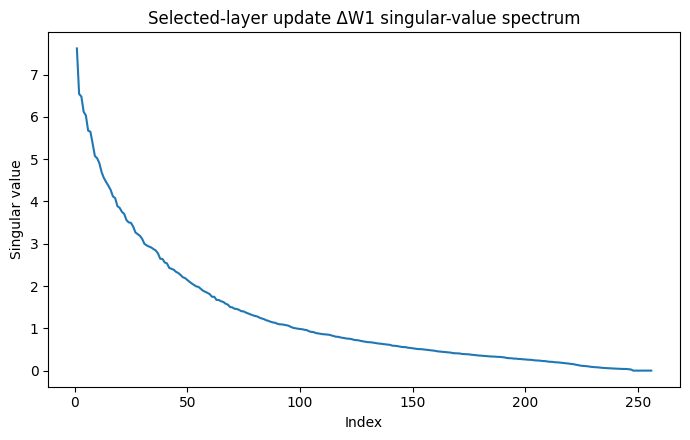

In [112]:
# Update spectrum for W1.
plot_data = pd.read_csv(RESULTS_DIR / "update_singular_values.csv")
layer_data = plot_data[plot_data["layer"] == "W1"]
figure, axis = plt.subplots(figsize=(7, 4.5))
axis.plot(layer_data["singular_value_index"], layer_data["singular_value"])
axis.set_xlabel("Index")
axis.set_ylabel("Singular value")
axis.set_title("Selected-layer update ΔW1 singular-value spectrum")
figure.tight_layout()
save_figure(figure, ADAPTATION_FIGURE_DIR, "update_singular_values_w1")
plt.show()


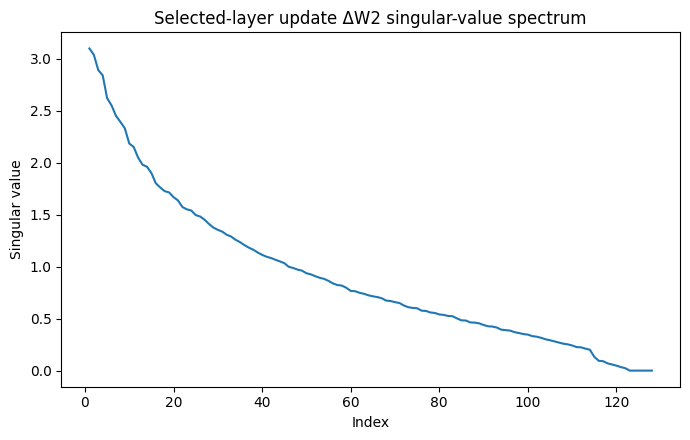

In [113]:
# Update spectrum for W2.
plot_data = pd.read_csv(RESULTS_DIR / "update_singular_values.csv")
layer_data = plot_data[plot_data["layer"] == "W2"]
figure, axis = plt.subplots(figsize=(7, 4.5))
axis.plot(layer_data["singular_value_index"], layer_data["singular_value"])
axis.set_xlabel("Index")
axis.set_ylabel("Singular value")
axis.set_title("Selected-layer update ΔW2 singular-value spectrum")
figure.tight_layout()
save_figure(figure, ADAPTATION_FIGURE_DIR, "update_singular_values_w2")
plt.show()


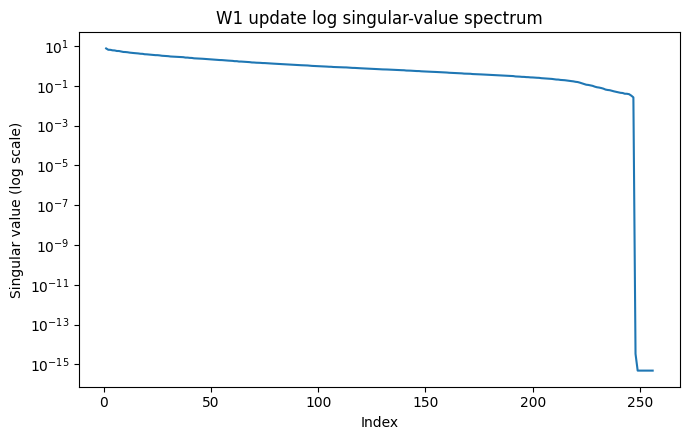

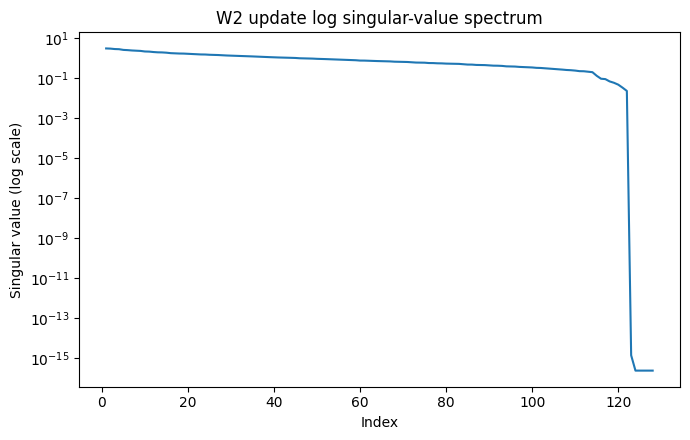

In [114]:
# Log-scale update spectra.
plot_data = pd.read_csv(RESULTS_DIR / "update_singular_values.csv")
for layer in ("W1", "W2"):
    layer_data = plot_data[plot_data["layer"] == layer]
    figure, axis = plt.subplots(figsize=(7, 4.5))
    axis.semilogy(layer_data["singular_value_index"], layer_data["singular_value"])
    axis.set_xlabel("Index")
    axis.set_ylabel("Singular value (log scale)")
    axis.set_title(f"{layer} update log singular-value spectrum")
    figure.tight_layout()
    save_figure(figure, ADAPTATION_FIGURE_DIR, f"update_singular_values_{layer.lower()}_log")
    plt.show()


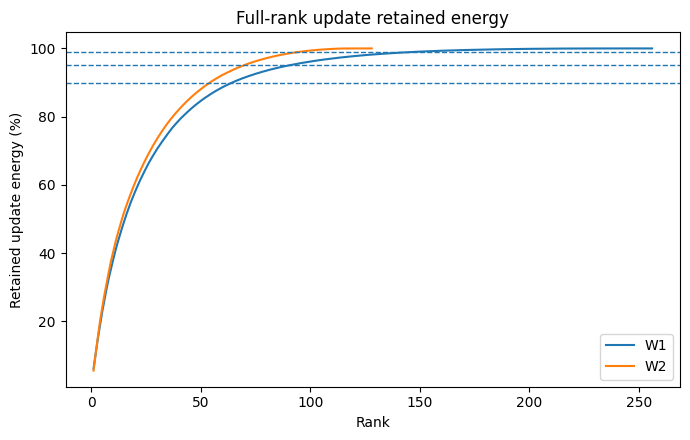

In [115]:
# Update retained energy.
plot_data = pd.read_csv(RESULTS_DIR / "update_singular_values.csv")
figure, axis = plt.subplots(figsize=(7, 4.5))
for layer in ("W1", "W2"):
    layer_data = plot_data[plot_data["layer"] == layer]
    axis.plot(
        layer_data["singular_value_index"],
        100 * layer_data["cumulative_retained_energy"],
        label=layer,
    )
for threshold in CONFIG["energy_thresholds"]:
    axis.axhline(100 * threshold, linestyle="--", linewidth=1)
axis.set_xlabel("Rank")
axis.set_ylabel("Retained update energy (%)")
axis.set_title("Full-rank update retained energy")
axis.legend()
figure.tight_layout()
save_figure(figure, ADAPTATION_FIGURE_DIR, "update_retained_energy")
plt.show()


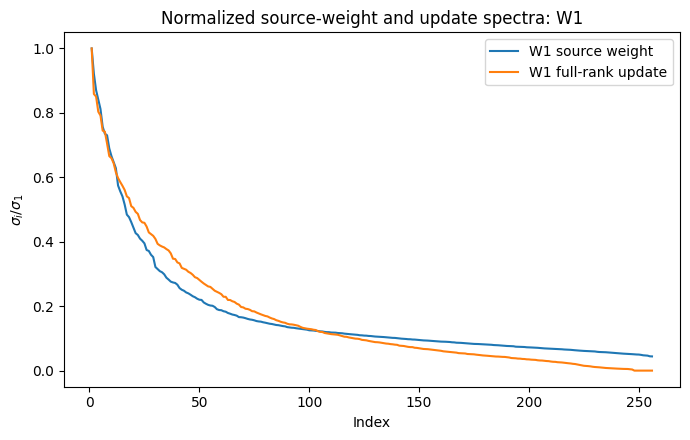

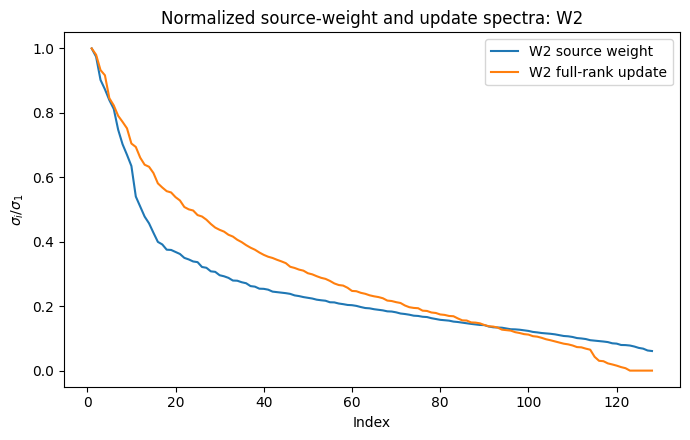

In [116]:
# Optional normalized comparison of source weights and target-task updates.
weight_data = pd.read_csv(RESULTS_DIR / "baseline_weight_singular_values.csv")
update_data = pd.read_csv(RESULTS_DIR / "update_singular_values.csv")
for layer in ("W1", "W2"):
    figure, axis = plt.subplots(figsize=(7, 4.5))
    base_layer = weight_data[weight_data["layer"] == layer]
    update_layer = update_data[update_data["layer"] == layer]
    axis.plot(
        base_layer["singular_value_index"],
        base_layer["normalized_singular_value"],
        label=f"{layer} source weight",
    )
    axis.plot(
        update_layer["singular_value_index"],
        update_layer["normalized_singular_value"],
        label=f"{layer} full-rank update",
    )
    axis.set_xlabel("Index")
    axis.set_ylabel(r"$\sigma_i / \sigma_1$")
    axis.set_title(f"Normalized source-weight and update spectra: {layer}")
    axis.legend()
    figure.tight_layout()
    save_figure(figure, ADAPTATION_FIGURE_DIR, f"weight_vs_update_spectrum_{layer.lower()}")
    plt.show()


# 17. Post hoc SVD compression of the full-rank update

In [117]:
class FixedLowRankAdapterLinear(nn.Module):
    def __init__(
        self,
        base_linear: nn.Linear,
        first_factor: torch.Tensor,
        second_factor: torch.Tensor,
    ) -> None:
        super().__init__()
        self.base = copy.deepcopy(base_linear)
        for parameter in self.base.parameters():
            parameter.requires_grad = False

        self.A = nn.Parameter(first_factor.clone(), requires_grad=False)
        self.B = nn.Parameter(second_factor.clone(), requires_grad=False)

    def forward(self, inputs: torch.Tensor) -> torch.Tensor:
        base_output = self.base(inputs)
        adapter_output = F.linear(F.linear(inputs, self.A), self.B)
        return base_output + adapter_output


In [118]:
def update_svd_factors(layer: str, rank: int) -> Tuple[torch.Tensor, torch.Tensor]:
    return svd_to_factors(UPDATE_SVDS[layer], rank, dtype=torch.float32)


def build_svd_update_model(rank_w1: int, rank_w2: int) -> FashionMLP:
    model = FashionMLP()
    model.load_state_dict(W0_STATE)
    a1, b1 = update_svd_factors("W1", rank_w1)
    a2, b2 = update_svd_factors("W2", rank_w2)
    model.fc1 = FixedLowRankAdapterLinear(model.fc1, a1, b1)
    model.fc2 = FixedLowRankAdapterLinear(model.fc2, a2, b2)
    for parameter in model.parameters():
        parameter.requires_grad = False
    return model.to(DEVICE)


In [120]:
# Fixed adapter versus explicitly materialized updated weight.
check_rank=16
check_a,check_b=update_svd_factors("W1",check_rank)
base_linear=nn.Linear(784,256)
base_linear.requires_grad_(False)
base_linear.weight.copy_(W0_STATE["fc1.weight"])
base_linear.bias.copy_(W0_STATE["fc1.bias"])
fixed_adapter=FixedLowRankAdapterLinear(base_linear,check_a,check_b).eval()
random_inputs=torch.randn(32,784)
materialized_weight=W0_STATE["fc1.weight"]+check_b@check_a
adapter_outputs=fixed_adapter(random_inputs)
materialized_outputs=F.linear(random_inputs,materialized_weight,W0_STATE["fc1.bias"])
# The additive and materialized GEMM paths differ slightly from float32 rounding.
assert torch.allclose(adapter_outputs,materialized_outputs,atol=1e-5,rtol=1e-5)
print("SVD additive-adapter equivalence check passed.")

SVD additive-adapter equivalence check passed.


In [121]:
def approximation_metrics(
    reference: torch.Tensor, approximation: torch.Tensor
) -> Dict[str, float]:
    reference = reference.to(torch.float64)
    approximation = approximation.to(torch.float64)
    error = torch.linalg.matrix_norm(reference - approximation).item()
    reference_norm = torch.linalg.matrix_norm(reference).item()
    relative = error / reference_norm
    # For SVD this equals classical retained energy. For an arbitrary LoRA
    # update it is an explicitly defined squared-error explained-energy score.
    explained_energy = 1.0 - relative ** 2
    return {
        "absolute_error": error,
        "relative_error": relative,
        "reference_energy_explained": explained_energy,
    }


def numerical_matrix_rank(
    matrix: torch.Tensor,
    *,
    source_dtype: torch.dtype = torch.float32,
) -> int:
    singular_values = torch.linalg.svdvals(matrix.detach().cpu().to(torch.float64))
    if singular_values.numel() == 0 or singular_values[0].item() == 0.0:
        return 0
    tolerance = (
        max(matrix.shape)
        * torch.finfo(source_dtype).eps
        * singular_values[0]
    )
    return int((singular_values > tolerance).sum().item())


def combined_relative_distance(
    reference_w1: torch.Tensor,
    approximation_w1: torch.Tensor,
    reference_w2: torch.Tensor,
    approximation_w2: torch.Tensor,
) -> float:
    numerator = math.sqrt(
        torch.linalg.matrix_norm(reference_w1 - approximation_w1).item() ** 2
        + torch.linalg.matrix_norm(reference_w2 - approximation_w2).item() ** 2
    )
    denominator = math.sqrt(
        torch.linalg.matrix_norm(reference_w1).item() ** 2
        + torch.linalg.matrix_norm(reference_w2).item() ** 2
    )
    return numerator / denominator


In [122]:
def evaluate_svd_update_configuration(
    rank_w1: int,
    rank_w2: int,
    configuration_tags: str,
) -> Dict[str, Any]:
    model = build_svd_update_model(rank_w1, rank_w2)
    target_validation = evaluate_model(model, target_validation_loader)
    target_test = evaluate_model(model, target_test_loader)
    source_test = evaluate_model(model, source_test_loader)

    a1, b1 = update_svd_factors("W1", rank_w1)
    a2, b2 = update_svd_factors("W2", rank_w2)
    approximation_w1 = (b1 @ a1).to(torch.float64)
    approximation_w2 = (b2 @ a2).to(torch.float64)
    metric_w1 = approximation_metrics(DELTA_W1_FR, approximation_w1)
    metric_w2 = approximation_metrics(DELTA_W2_FR, approximation_w2)

    row = {
        "method": "svd_compressed_update",
        "configuration_tags": configuration_tags,
        "rank_w1": rank_w1,
        "rank_w2": rank_w2,
        "numerical_rank_w1": numerical_matrix_rank(approximation_w1),
        "numerical_rank_w2": numerical_matrix_rank(approximation_w2),
        "seed": CONFIG["seed"],
        "target_validation_loss": target_validation["loss"],
        "target_validation_accuracy": target_validation["accuracy"],
        "target_test_loss": target_test["loss"],
        "target_test_accuracy": target_test["accuracy"],
        "source_test_loss": source_test["loss"],
        "source_test_accuracy": source_test["accuracy"],
        "target_accuracy_gap_from_selected_full_rank_pp": 100 * (
            selected_metrics["target_test_accuracy"] - target_test["accuracy"]
        ),
        "source_accuracy_drop_from_w0_pp": 100 * (
            baseline_metrics["source_test_accuracy"] - source_test["accuracy"]
        ),
        "absolute_update_error_w1": metric_w1["absolute_error"],
        "relative_update_error_w1": metric_w1["relative_error"],
        "reference_update_energy_explained_w1": metric_w1["reference_energy_explained"],
        "absolute_update_error_w2": metric_w2["absolute_error"],
        "relative_update_error_w2": metric_w2["relative_error"],
        "reference_update_energy_explained_w2": metric_w2["reference_energy_explained"],
        "combined_relative_update_distance": combined_relative_distance(
            DELTA_W1_FR, approximation_w1, DELTA_W2_FR, approximation_w2
        ),
        "training_time_trainable_parameters": SELECTED_WEIGHT_PARAMETER_COUNT,
        "task_specific_stored_parameters": 1040 * rank_w1 + 384 * rank_w2,
        "base_model_parameters": BASELINE_PARAMETER_COUNT,
        "unmerged_package_parameters": (
            BASELINE_PARAMETER_COUNT + 1040 * rank_w1 + 384 * rank_w2
        ),
        "merged_dense_deployment_parameters": BASELINE_PARAMETER_COUNT,
        "evaluation_model_trainable_parameters": 0,
        "best_epoch": selected_metadata["best_epoch"],
        "learning_rate": 0.0,
    }
    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return row


In [123]:
def update_energy_rank(layer: str, threshold: float) -> int:
    row = update_energy_thresholds[
        (update_energy_thresholds["layer"] == layer)
        & np.isclose(update_energy_thresholds["energy_threshold"], threshold)
    ]
    if len(row) != 1:
        raise RuntimeError("Update energy-rank lookup was not unique.")
    return int(row.iloc[0]["minimum_rank"])


svd_configuration_tags: Dict[Tuple[int, int], List[str]] = {}
for rank in CONFIG["adaptation_same_rank_grid"]:
    svd_configuration_tags.setdefault((rank, rank), []).append("same_rank")
if not CONFIG["fast_dev_run"]:
    for threshold in CONFIG["energy_thresholds"]:
        pair = (
            update_energy_rank("W1", threshold),
            update_energy_rank("W2", threshold),
        )
        svd_configuration_tags.setdefault(pair, []).append(f"energy_{int(100 * threshold)}")
    svd_configuration_tags.setdefault((256, 128), []).append("exact_pair")
svd_configuration_tags


{(1, 1): ['same_rank'],
 (2, 2): ['same_rank'],
 (4, 4): ['same_rank'],
 (8, 8): ['same_rank'],
 (16, 16): ['same_rank'],
 (32, 32): ['same_rank'],
 (64, 64): ['same_rank'],
 (96, 96): ['same_rank'],
 (128, 128): ['same_rank'],
 (65, 55): ['energy_90'],
 (90, 70): ['energy_95'],
 (148, 95): ['energy_99'],
 (256, 128): ['exact_pair']}

In [124]:
svd_update_rows: List[Dict[str, Any]] = []
for (rank_w1, rank_w2), tags in sorted(svd_configuration_tags.items()):
    svd_update_rows.append(
        evaluate_svd_update_configuration(rank_w1, rank_w2, "|".join(tags))
    )
    print(f"Evaluated SVD update pair ({rank_w1}, {rank_w2}).")


Evaluated SVD update pair (1, 1).
Evaluated SVD update pair (2, 2).
Evaluated SVD update pair (4, 4).
Evaluated SVD update pair (8, 8).
Evaluated SVD update pair (16, 16).
Evaluated SVD update pair (32, 32).
Evaluated SVD update pair (64, 64).
Evaluated SVD update pair (65, 55).
Evaluated SVD update pair (90, 70).
Evaluated SVD update pair (96, 96).
Evaluated SVD update pair (128, 128).
Evaluated SVD update pair (148, 95).
Evaluated SVD update pair (256, 128).


In [125]:
# Exact update reconstruction must reproduce the selected-layer reference.
if CONFIG["fast_dev_run"]:
    print("FAST_DEV_RUN: skipped the exact SVD-update classifier evaluation.")
else:
    exact_svd_model = build_svd_update_model(256, 128)
    selected_predictions = collect_predictions(selected_model, target_test_loader)
    exact_svd_predictions = collect_predictions(exact_svd_model, target_test_loader)
    assert torch.equal(selected_predictions, exact_svd_predictions)
    print("Exact SVD update pair reproduces all selected-reference target-test predictions.")


Exact SVD update pair reproduces all selected-reference target-test predictions.


In [126]:
svd_update_results = pd.DataFrame(svd_update_rows).sort_values(
    ["rank_w1", "rank_w2"]
).reset_index(drop=True)
assert not svd_update_results.isna().any().any()
svd_update_results.to_csv(RESULTS_DIR / "svd_update_sweep.csv", index=False)
svd_update_results


,method,configuration_tags,rank_w1,rank_w2,numerical_rank_w1,numerical_rank_w2,seed,target_validation_loss,target_validation_accuracy,target_test_loss,...,reference_update_energy_explained_w2,combined_relative_update_distance,training_time_trainable_parameters,task_specific_stored_parameters,base_model_parameters,unmerged_package_parameters,merged_dense_deployment_parameters,evaluation_model_trainable_parameters,best_epoch,learning_rate
0,svd_compressed_update,same_rank,1,1,1,1,42,1.794474,0.478333,1.791673,...,0.055139,9.692823e-01,233472,1424,235146,236570,235146,0,15,0.0
1,svd_compressed_update,same_rank,2,2,2,2,42,1.224477,0.609333,1.255714,...,0.108137,9.449826e-01,233472,2848,235146,237994,235146,0,15,0.0
2,svd_compressed_update,same_rank,4,4,4,4,42,1.776655,0.584500,1.709963,...,0.202451,8.984582e-01,233472,5696,235146,240842,235146,0,15,0.0
3,svd_compressed_update,same_rank,8,8,8,8,42,0.988238,0.675167,1.010731,...,0.346596,8.179918e-01,233472,11392,235146,246538,235146,0,15,0.0
4,svd_compressed_update,same_rank,16,16,16,16,42,0.585436,0.813500,0.608727,...,0.539789,6.946573e-01,233472,22784,235146,257930,235146,0,15,0.0
5,svd_compressed_update,same_rank,32,32,32,32,42,0.373609,0.876667,0.411360,...,0.755036,5.207466e-01,233472,45568,235146,280714,235146,0,15,0.0
6,svd_compressed_update,same_rank,64,64,64,64,42,0.309413,0.892833,0.337448,...,0.935328,3.085714e-01,233472,91136,235146,326282,235146,0,15,0.0
7,svd_compressed_update,energy_90,65,55,65,55,42,0.309225,0.893333,0.338772,...,0.903833,3.125952e-01,233472,88720,235146,323866,235146,0,15,0.0
8,svd_compressed_update,energy_95,90,70,90,70,42,0.299311,0.896500,0.331514,...,0.951584,2.228995e-01,233472,120480,235146,355626,235146,0,15,0.0
9,svd_compressed_update,same_rank,96,96,96,96,42,0.298762,0.895833,0.329784,...,0.990941,1.933133e-01,233472,136704,235146,371850,235146,0,15,0.0


# 18. Direct LoRA adaptation

In [127]:
class LoRALinear(nn.Module):
    def __init__(
        self,
        base_linear: nn.Linear,
        rank: int,
        alpha: Optional[float] = None,
        initialization_std: float = 0.01,
    ) -> None:
        super().__init__()
        if rank < 1:
            raise ValueError("LoRA rank must be positive.")
        self.rank = int(rank)
        self.alpha = float(rank if alpha is None else alpha)
        self.scaling = self.alpha / self.rank

        self.base = copy.deepcopy(base_linear)
        for parameter in self.base.parameters():
            parameter.requires_grad = False

        self.A = nn.Parameter(torch.empty(rank, base_linear.in_features))
        self.B = nn.Parameter(torch.zeros(base_linear.out_features, rank))
        nn.init.normal_(self.A, mean=0.0, std=initialization_std)

    def forward(self, inputs: torch.Tensor) -> torch.Tensor:
        base_output = self.base(inputs)
        adapter_output = F.linear(F.linear(inputs, self.A), self.B)
        return base_output + self.scaling * adapter_output

    def dense_update(self) -> torch.Tensor:
        return self.scaling * (self.B @ self.A)


In [128]:
def build_lora_model(rank_w1: int, rank_w2: int) -> FashionMLP:
    model = FashionMLP()
    model.load_state_dict(W0_STATE)
    model.fc1 = LoRALinear(model.fc1, rank_w1, alpha=rank_w1)
    model.fc2 = LoRALinear(model.fc2, rank_w2, alpha=rank_w2)
    for parameter in model.fc3.parameters():
        parameter.requires_grad = False
    return model.to(DEVICE)


def expected_lora_parameter_count(rank_w1: int, rank_w2: int) -> int:
    return 1040 * rank_w1 + 384 * rank_w2


In [129]:
# At initialization, B=0, so LoRA must exactly match W0.
seed_everything(CONFIG["lora_initialization_seed"])
initial_lora_model = build_lora_model(16, 16)
initial_base_model = FashionMLP().to(DEVICE)
initial_base_model.load_state_dict(W0_STATE)
random_images = torch.randn(32, 1, 28, 28, device=DEVICE)
with torch.inference_mode():
    base_logits = initial_base_model(random_images)
    lora_logits = initial_lora_model(random_images)
assert torch.equal(base_logits, lora_logits)
print("Initial LoRA output exactly matches W0.")


Initial LoRA output exactly matches W0.


In [130]:
# Trainability and parameter-count audit.
expected_names = {"fc1.A", "fc1.B", "fc2.A", "fc2.B"}
actual_names = {
    name for name, parameter in initial_lora_model.named_parameters() if parameter.requires_grad
}
assert actual_names == expected_names
assert parameter_counts(initial_lora_model)["trainable"] == expected_lora_parameter_count(16, 16)
gradient_audit(initial_lora_model, target_train_loader_preview, sorted(expected_names))
print("LoRA trainability audit passed.")


LoRA trainability audit passed.


In [131]:
# Validation-only learning-rate pilot at rank 16. No target-test loader appears here.
lora_pilot_path = RESULTS_DIR / "lora_learning_rate_pilot.csv"
reuse_pilot = CONFIG["reuse_cached_checkpoints"] and lora_pilot_path.exists()

if reuse_pilot:
    lora_pilot_results = pd.read_csv(lora_pilot_path)
    if set(lora_pilot_results["config_signature"]) != {CONFIG_SIGNATURE}:
        reuse_pilot = False

if not reuse_pilot:
    pilot_rows: List[Dict[str, Any]] = []
    for learning_rate in CONFIG["lora_learning_rate_candidates"]:
        seed_everything(CONFIG["lora_initialization_seed"])
        pilot_model = build_lora_model(
            CONFIG["lora_pilot_rank"], CONFIG["lora_pilot_rank"]
        )
        pilot_model, _, pilot_metadata = fit_model(
            pilot_model,
            target_train_dataset,
            target_validation_loader,
            epochs=CONFIG["adaptation_epochs"],
            learning_rate=learning_rate,
            loader_seed=CONFIG["loader_seed"],
            label=f"lora_lr_pilot_{learning_rate:g}",
        )
        pilot_rows.append(
            {
                "rank_w1": CONFIG["lora_pilot_rank"],
                "rank_w2": CONFIG["lora_pilot_rank"],
                "learning_rate": learning_rate,
                "best_validation_loss": pilot_metadata["best_validation_loss"],
                "best_validation_accuracy": pilot_metadata["best_validation_accuracy"],
                "best_epoch": pilot_metadata["best_epoch"],
                "config_signature": CONFIG_SIGNATURE,
            }
        )
        del pilot_model
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
    lora_pilot_results = pd.DataFrame(pilot_rows)
    lora_pilot_results.to_csv(lora_pilot_path, index=False)

lora_pilot_results


lora_lr_pilot_0.001 | epoch 01/15 | train loss 0.6706 | val loss 0.5281 | val acc 81.10%
lora_lr_pilot_0.001 | epoch 02/15 | train loss 0.4544 | val loss 0.4375 | val acc 84.78%
lora_lr_pilot_0.001 | epoch 03/15 | train loss 0.3931 | val loss 0.4020 | val acc 86.07%
lora_lr_pilot_0.001 | epoch 04/15 | train loss 0.3600 | val loss 0.3850 | val acc 85.95%
lora_lr_pilot_0.001 | epoch 05/15 | train loss 0.3445 | val loss 0.3823 | val acc 86.25%
lora_lr_pilot_0.001 | epoch 06/15 | train loss 0.3276 | val loss 0.3638 | val acc 86.63%
lora_lr_pilot_0.001 | epoch 07/15 | train loss 0.3174 | val loss 0.3526 | val acc 87.17%
lora_lr_pilot_0.001 | epoch 08/15 | train loss 0.3070 | val loss 0.3453 | val acc 87.85%
lora_lr_pilot_0.001 | epoch 09/15 | train loss 0.2999 | val loss 0.3459 | val acc 87.53%
lora_lr_pilot_0.001 | epoch 10/15 | train loss 0.2924 | val loss 0.3404 | val acc 87.63%
lora_lr_pilot_0.001 | epoch 11/15 | train loss 0.2857 | val loss 0.3295 | val acc 88.37%
lora_lr_pilot_0.001 |

,rank_w1,rank_w2,learning_rate,best_validation_loss,best_validation_accuracy,best_epoch,config_signature
0,16,16,0.001,0.327721,0.883667,15,27036506a35f2930
1,16,16,0.003,0.333189,0.878833,7,27036506a35f2930


In [132]:
# Select by minimum validation loss; a lower learning rate wins an exact tie.
selected_pilot_row = lora_pilot_results.sort_values(
    ["best_validation_loss", "learning_rate"]
).iloc[0]
LORA_LEARNING_RATE = float(selected_pilot_row["learning_rate"])
CONFIG["lora_selected_learning_rate"] = LORA_LEARNING_RATE

with (CONFIG_DIR / "experiment_config.json").open("w", encoding="utf-8") as handle:
    json.dump(CONFIG, handle, indent=2)

print("Locked final LoRA learning rate:", LORA_LEARNING_RATE)


Locked final LoRA learning rate: 0.001


In [133]:
def adapter_state_dict(model: nn.Module) -> Dict[str, torch.Tensor]:
    return {
        name: tensor.detach().cpu().clone()
        for name, tensor in model.state_dict().items()
        if name in {"fc1.A", "fc1.B", "fc2.A", "fc2.B"}
    }


def load_adapter_state(model: nn.Module, state: Dict[str, torch.Tensor]) -> None:
    current = model.state_dict()
    current.update(state)
    model.load_state_dict(current)


def save_lora_checkpoint(
    path: Path,
    model: FashionMLP,
    rank_w1: int,
    rank_w2: int,
    metadata: Dict[str, Any],
) -> None:
    adapter_state = adapter_state_dict(model)
    assert set(adapter_state) == {"fc1.A", "fc1.B", "fc2.A", "fc2.B"}
    payload = {
        "adapter_state_dict": adapter_state,
        "rank_w1": rank_w1,
        "rank_w2": rank_w2,
        "alpha_w1": rank_w1,
        "alpha_w2": rank_w2,
        "learning_rate": LORA_LEARNING_RATE,
        "best_epoch": int(metadata["best_epoch"]),
        "best_validation_loss": float(metadata["best_validation_loss"]),
        "best_validation_accuracy": float(metadata["best_validation_accuracy"]),
        "seed": CONFIG["lora_initialization_seed"],
        "config": copy.deepcopy(CONFIG),
        "config_signature": CONFIG_SIGNATURE,
    }
    torch.save(payload, path)


In [134]:
def assert_lora_base_unchanged(model: FashionMLP) -> None:
    assert isinstance(model.fc1, LoRALinear)
    assert isinstance(model.fc2, LoRALinear)
    checks = {
        "fc1.weight": model.fc1.base.weight,
        "fc1.bias": model.fc1.base.bias,
        "fc2.weight": model.fc2.base.weight,
        "fc2.bias": model.fc2.base.bias,
        "fc3.weight": model.fc3.weight,
        "fc3.bias": model.fc3.bias,
    }
    for name, tensor in checks.items():
        assert torch.equal(tensor.detach().cpu(), W0_STATE[name])


In [135]:
def train_or_load_lora(
    rank_w1: int,
    rank_w2: int,
) -> Tuple[FashionMLP, pd.DataFrame, Dict[str, Any]]:
    checkpoint_path = LORA_CHECKPOINT_DIR / f"lora_r{rank_w1}_r{rank_w2}.pt"
    history_path = RESULTS_DIR / f"lora_history_r{rank_w1}_r{rank_w2}.csv"

    can_reuse = (
        CONFIG["reuse_cached_checkpoints"]
        and checkpoint_path.exists()
        and history_path.exists()
    )
    seed_everything(CONFIG["lora_initialization_seed"])
    model = build_lora_model(rank_w1, rank_w2)

    if can_reuse:
        payload = safe_torch_load(checkpoint_path)
        if payload.get("config_signature") != CONFIG_SIGNATURE:
            raise ValueError(f"Incompatible LoRA checkpoint: {checkpoint_path.name}")
        if float(payload.get("learning_rate")) != LORA_LEARNING_RATE:
            raise ValueError(f"LoRA learning-rate mismatch: {checkpoint_path.name}")
        load_adapter_state(model, payload["adapter_state_dict"])
        history = pd.read_csv(history_path)
        metadata = {
            "best_epoch": int(payload["best_epoch"]),
            "best_validation_loss": float(payload["best_validation_loss"]),
            "best_validation_accuracy": float(payload["best_validation_accuracy"]),
        }
    else:
        model, history, metadata = fit_model(
            model,
            target_train_dataset,
            target_validation_loader,
            epochs=CONFIG["adaptation_epochs"],
            learning_rate=LORA_LEARNING_RATE,
            loader_seed=CONFIG["loader_seed"],
            label=f"lora_r{rank_w1}_r{rank_w2}",
        )
        save_lora_checkpoint(checkpoint_path, model, rank_w1, rank_w2, metadata)
        history.to_csv(history_path, index=False)

    assert_lora_base_unchanged(model)
    assert parameter_counts(model)["trainable"] == expected_lora_parameter_count(
        rank_w1, rank_w2
    )
    return model, history, metadata


In [136]:
lora_configuration_tags: Dict[Tuple[int, int], List[str]] = {}
for rank in CONFIG["adaptation_same_rank_grid"]:
    lora_configuration_tags.setdefault((rank, rank), []).append("same_rank")
if not CONFIG["fast_dev_run"]:
    for threshold in CONFIG["energy_thresholds"]:
        pair = (
            update_energy_rank("W1", threshold),
            update_energy_rank("W2", threshold),
        )
        lora_configuration_tags.setdefault(pair, []).append(f"energy_{int(100 * threshold)}")
lora_configuration_tags


{(1, 1): ['same_rank'],
 (2, 2): ['same_rank'],
 (4, 4): ['same_rank'],
 (8, 8): ['same_rank'],
 (16, 16): ['same_rank'],
 (32, 32): ['same_rank'],
 (64, 64): ['same_rank'],
 (96, 96): ['same_rank'],
 (128, 128): ['same_rank'],
 (65, 55): ['energy_90'],
 (90, 70): ['energy_95'],
 (148, 95): ['energy_99']}

In [137]:
def evaluate_lora_configuration(
    model: FashionMLP,
    rank_w1: int,
    rank_w2: int,
    configuration_tags: str,
    metadata: Dict[str, Any],
) -> Dict[str, Any]:
    target_validation = evaluate_model(model, target_validation_loader)
    target_test = evaluate_model(model, target_test_loader)
    source_test = evaluate_model(model, source_test_loader)

    approximation_w1 = model.fc1.dense_update().detach().cpu().to(torch.float64)
    approximation_w2 = model.fc2.dense_update().detach().cpu().to(torch.float64)
    metric_w1 = approximation_metrics(DELTA_W1_FR, approximation_w1)
    metric_w2 = approximation_metrics(DELTA_W2_FR, approximation_w2)
    numerical_rank_w1 = numerical_matrix_rank(approximation_w1)
    numerical_rank_w2 = numerical_matrix_rank(approximation_w2)
    assert numerical_rank_w1 <= rank_w1
    assert numerical_rank_w2 <= rank_w2

    return {
        "method": "lora",
        "configuration_tags": configuration_tags,
        "rank_w1": rank_w1,
        "rank_w2": rank_w2,
        "numerical_rank_w1": numerical_rank_w1,
        "numerical_rank_w2": numerical_rank_w2,
        "seed": CONFIG["lora_initialization_seed"],
        "target_validation_loss": target_validation["loss"],
        "target_validation_accuracy": target_validation["accuracy"],
        "target_test_loss": target_test["loss"],
        "target_test_accuracy": target_test["accuracy"],
        "source_test_loss": source_test["loss"],
        "source_test_accuracy": source_test["accuracy"],
        "target_accuracy_gap_from_selected_full_rank_pp": 100 * (
            selected_metrics["target_test_accuracy"] - target_test["accuracy"]
        ),
        "source_accuracy_drop_from_w0_pp": 100 * (
            baseline_metrics["source_test_accuracy"] - source_test["accuracy"]
        ),
        "absolute_update_error_w1": metric_w1["absolute_error"],
        "relative_update_error_w1": metric_w1["relative_error"],
        "reference_update_energy_explained_w1": metric_w1["reference_energy_explained"],
        "absolute_update_error_w2": metric_w2["absolute_error"],
        "relative_update_error_w2": metric_w2["relative_error"],
        "reference_update_energy_explained_w2": metric_w2["reference_energy_explained"],
        "combined_relative_update_distance": combined_relative_distance(
            DELTA_W1_FR, approximation_w1, DELTA_W2_FR, approximation_w2
        ),
        "training_time_trainable_parameters": expected_lora_parameter_count(
            rank_w1, rank_w2
        ),
        "task_specific_stored_parameters": expected_lora_parameter_count(
            rank_w1, rank_w2
        ),
        "base_model_parameters": BASELINE_PARAMETER_COUNT,
        "unmerged_package_parameters": (
            BASELINE_PARAMETER_COUNT
            + expected_lora_parameter_count(rank_w1, rank_w2)
        ),
        "merged_dense_deployment_parameters": BASELINE_PARAMETER_COUNT,
        "evaluation_model_trainable_parameters": expected_lora_parameter_count(
            rank_w1, rank_w2
        ),
        "best_epoch": metadata["best_epoch"],
        "learning_rate": LORA_LEARNING_RATE,
    }


In [138]:
lora_rows: List[Dict[str, Any]] = []
lora_histories: List[pd.DataFrame] = []
for (rank_w1, rank_w2), tags in sorted(lora_configuration_tags.items()):
    seed_everything(CONFIG["lora_initialization_seed"])
    lora_model, lora_history, lora_metadata = train_or_load_lora(rank_w1, rank_w2)
    lora_rows.append(
        evaluate_lora_configuration(
            lora_model, rank_w1, rank_w2, "|".join(tags), lora_metadata
        )
    )
    history_copy = lora_history.copy()
    history_copy["rank_w1"] = rank_w1
    history_copy["rank_w2"] = rank_w2
    lora_histories.append(history_copy)
    print(f"Completed LoRA pair ({rank_w1}, {rank_w2}).")
    del lora_model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


lora_r1_r1 | epoch 01/15 | train loss 0.8932 | val loss 0.7310 | val acc 73.87%
lora_r1_r1 | epoch 02/15 | train loss 0.6816 | val loss 0.6949 | val acc 74.87%
lora_r1_r1 | epoch 03/15 | train loss 0.6572 | val loss 0.6705 | val acc 75.35%
lora_r1_r1 | epoch 04/15 | train loss 0.6385 | val loss 0.6535 | val acc 75.68%
lora_r1_r1 | epoch 05/15 | train loss 0.6236 | val loss 0.6409 | val acc 76.38%
lora_r1_r1 | epoch 06/15 | train loss 0.6090 | val loss 0.6245 | val acc 76.98%
lora_r1_r1 | epoch 07/15 | train loss 0.5958 | val loss 0.6127 | val acc 77.40%
lora_r1_r1 | epoch 08/15 | train loss 0.5849 | val loss 0.6023 | val acc 77.92%
lora_r1_r1 | epoch 09/15 | train loss 0.5754 | val loss 0.5919 | val acc 78.58%
lora_r1_r1 | epoch 10/15 | train loss 0.5670 | val loss 0.5836 | val acc 78.70%
lora_r1_r1 | epoch 11/15 | train loss 0.5597 | val loss 0.5761 | val acc 79.62%
lora_r1_r1 | epoch 12/15 | train loss 0.5537 | val loss 0.5737 | val acc 79.40%
lora_r1_r1 | epoch 13/15 | train loss 0.

In [139]:
lora_results = pd.DataFrame(lora_rows).sort_values(
    ["rank_w1", "rank_w2"]
).reset_index(drop=True)
assert not lora_results.isna().any().any()
lora_results.to_csv(RESULTS_DIR / "lora_sweep.csv", index=False)

lora_training_histories = pd.concat(lora_histories, ignore_index=True)
lora_training_histories.to_csv(
    RESULTS_DIR / "lora_training_histories.csv", index=False
)
lora_results


,method,configuration_tags,rank_w1,rank_w2,numerical_rank_w1,numerical_rank_w2,seed,target_validation_loss,target_validation_accuracy,target_test_loss,...,reference_update_energy_explained_w2,combined_relative_update_distance,training_time_trainable_parameters,task_specific_stored_parameters,base_model_parameters,unmerged_package_parameters,merged_dense_deployment_parameters,evaluation_model_trainable_parameters,best_epoch,learning_rate
0,lora,same_rank,1,1,1,1,42,0.559309,0.802833,0.563609,...,-1.379171,1.424817,1424,1424,235146,236570,235146,1424,15,0.001
1,lora,same_rank,2,2,2,2,42,0.460315,0.838000,0.466087,...,-1.454418,1.210475,2848,2848,235146,237994,235146,2848,15,0.001
2,lora,same_rank,4,4,4,4,42,0.368164,0.864167,0.394150,...,-1.153710,1.170225,5696,5696,235146,240842,235146,5696,15,0.001
3,lora,same_rank,8,8,8,8,42,0.347812,0.872500,0.364884,...,-1.188563,1.183827,11392,11392,235146,246538,235146,11392,15,0.001
4,lora,same_rank,16,16,16,16,42,0.327721,0.883667,0.339110,...,-1.398957,1.241410,22784,22784,235146,257930,235146,22784,15,0.001
5,lora,same_rank,32,32,32,32,42,0.320914,0.885000,0.348509,...,-1.679048,1.300901,45568,45568,235146,280714,235146,45568,13,0.001
6,lora,same_rank,64,64,64,64,42,0.312825,0.889500,0.334065,...,-1.834625,1.400031,91136,91136,235146,326282,235146,91136,12,0.001
7,lora,energy_90,65,55,65,55,42,0.317000,0.888000,0.339252,...,-1.576331,1.390814,88720,88720,235146,323866,235146,88720,12,0.001
8,lora,energy_95,90,70,90,70,42,0.303563,0.892333,0.329339,...,-1.606012,1.510180,120480,120480,235146,355626,235146,120480,13,0.001
9,lora,same_rank,96,96,96,96,42,0.309818,0.884667,0.341331,...,-1.966980,1.528746,136704,136704,235146,371850,235146,136704,13,0.001


# 19. Combined adaptation results table

In [140]:
# Extract the first-two-layer updates of unrestricted fine-tuning so every
# reference row has well-defined distances from the selected-layer reference.
unrestricted_state = clone_state_dict(unrestricted_model.state_dict())
DELTA_W1_UNRESTRICTED = (
    unrestricted_state["fc1.weight"] - W0_STATE["fc1.weight"]
).to(torch.float64)
DELTA_W2_UNRESTRICTED = (
    unrestricted_state["fc2.weight"] - W0_STATE["fc2.weight"]
).to(torch.float64)
ZERO_UPDATE_W1 = torch.zeros_like(DELTA_W1_FR)
ZERO_UPDATE_W2 = torch.zeros_like(DELTA_W2_FR)


In [141]:
def reference_adaptation_row(
    method: str,
    metrics: Dict[str, Any],
    approximation_w1: torch.Tensor,
    approximation_w2: torch.Tensor,
    rank_w1: int,
    rank_w2: int,
    training_parameters: int,
    stored_parameters: int,
    best_epoch: int,
) -> Dict[str, Any]:
    metric_w1 = approximation_metrics(DELTA_W1_FR, approximation_w1)
    metric_w2 = approximation_metrics(DELTA_W2_FR, approximation_w2)
    return {
        "method": method,
        "configuration_tags": "reference",
        "rank_w1": rank_w1,
        "rank_w2": rank_w2,
        "numerical_rank_w1": numerical_matrix_rank(approximation_w1),
        "numerical_rank_w2": numerical_matrix_rank(approximation_w2),
        "seed": CONFIG["seed"],
        "target_validation_loss": metrics["target_validation_loss"],
        "target_validation_accuracy": metrics["target_validation_accuracy"],
        "target_test_loss": metrics["target_test_loss"],
        "target_test_accuracy": metrics["target_test_accuracy"],
        "source_test_loss": metrics["source_test_loss"],
        "source_test_accuracy": metrics["source_test_accuracy"],
        "target_accuracy_gap_from_selected_full_rank_pp": 100 * (
            selected_metrics["target_test_accuracy"] - metrics["target_test_accuracy"]
        ),
        "source_accuracy_drop_from_w0_pp": 100 * (
            baseline_metrics["source_test_accuracy"] - metrics["source_test_accuracy"]
        ),
        "absolute_update_error_w1": metric_w1["absolute_error"],
        "relative_update_error_w1": metric_w1["relative_error"],
        "reference_update_energy_explained_w1": metric_w1["reference_energy_explained"],
        "absolute_update_error_w2": metric_w2["absolute_error"],
        "relative_update_error_w2": metric_w2["relative_error"],
        "reference_update_energy_explained_w2": metric_w2["reference_energy_explained"],
        "combined_relative_update_distance": combined_relative_distance(
            DELTA_W1_FR, approximation_w1, DELTA_W2_FR, approximation_w2
        ),
        "training_time_trainable_parameters": training_parameters,
        "task_specific_stored_parameters": stored_parameters,
        "base_model_parameters": BASELINE_PARAMETER_COUNT,
        "unmerged_package_parameters": (
            BASELINE_PARAMETER_COUNT
            if method in {"source_baseline_zero_shot", "unrestricted_full_finetuning"}
            else BASELINE_PARAMETER_COUNT + stored_parameters
        ),
        "merged_dense_deployment_parameters": BASELINE_PARAMETER_COUNT,
        "evaluation_model_trainable_parameters": training_parameters,
        "best_epoch": best_epoch,
        "learning_rate": 0.0 if training_parameters == 0 else CONFIG["target_learning_rate"],
    }


In [142]:
reference_rows = [
    reference_adaptation_row(
        "source_baseline_zero_shot",
        zero_shot_metrics,
        ZERO_UPDATE_W1,
        ZERO_UPDATE_W2,
        0,
        0,
        0,
        0,
        0,
    ),
    reference_adaptation_row(
        "unrestricted_full_finetuning",
        unrestricted_metrics,
        DELTA_W1_UNRESTRICTED,
        DELTA_W2_UNRESTRICTED,
        256,
        128,
        BASELINE_PARAMETER_COUNT,
        BASELINE_PARAMETER_COUNT,
        unrestricted_metadata["best_epoch"],
    ),
    reference_adaptation_row(
        "selected_layer_full_rank",
        selected_metrics,
        DELTA_W1_FR,
        DELTA_W2_FR,
        256,
        128,
        SELECTED_WEIGHT_PARAMETER_COUNT,
        SELECTED_WEIGHT_PARAMETER_COUNT,
        selected_metadata["best_epoch"],
    ),
]

adaptation_comparison = pd.concat(
    [
        pd.DataFrame(reference_rows),
        svd_update_results.assign(learning_rate=0.0),
        lora_results,
    ],
    ignore_index=True,
)
adaptation_comparison = adaptation_comparison.sort_values(
    ["method", "rank_w1", "rank_w2"]
).reset_index(drop=True)
assert not adaptation_comparison.isna().any().any()
adaptation_comparison.to_csv(
    RESULTS_DIR / "adaptation_comparison.csv", index=False
)
adaptation_comparison.head()


,method,configuration_tags,rank_w1,rank_w2,numerical_rank_w1,numerical_rank_w2,seed,target_validation_loss,target_validation_accuracy,target_test_loss,...,reference_update_energy_explained_w2,combined_relative_update_distance,training_time_trainable_parameters,task_specific_stored_parameters,base_model_parameters,unmerged_package_parameters,merged_dense_deployment_parameters,evaluation_model_trainable_parameters,best_epoch,learning_rate
0,lora,same_rank,1,1,1,1,42,0.559309,0.802833,0.563609,...,-1.379171,1.424817,1424,1424,235146,236570,235146,1424,15,0.001
1,lora,same_rank,2,2,2,2,42,0.460315,0.838000,0.466087,...,-1.454418,1.210475,2848,2848,235146,237994,235146,2848,15,0.001
2,lora,same_rank,4,4,4,4,42,0.368164,0.864167,0.394150,...,-1.153710,1.170225,5696,5696,235146,240842,235146,5696,15,0.001
3,lora,same_rank,8,8,8,8,42,0.347812,0.872500,0.364884,...,-1.188563,1.183827,11392,11392,235146,246538,235146,11392,15,0.001
4,lora,same_rank,16,16,16,16,42,0.327721,0.883667,0.339110,...,-1.398957,1.241410,22784,22784,235146,257930,235146,22784,15,0.001


In [143]:
# A compact cross-part table with one consistent schema.
all_evaluation_rows: List[Dict[str, Any]] = []
for _, row in compression_results.iterrows():
    all_evaluation_rows.append(
        {
            "experiment_part": "source_compression",
            "evaluation_domain": "source",
            "method": row["method"],
            "rank_w1": int(row["rank_w1"]),
            "rank_w2": int(row["rank_w2"]),
            "validation_loss": row["source_validation_loss"],
            "validation_accuracy": row["source_validation_accuracy"],
            "test_loss": row["source_test_loss"],
            "test_accuracy": row["source_test_accuracy"],
            "source_test_loss": row["source_test_loss"],
            "source_test_accuracy": row["source_test_accuracy"],
            "total_or_base_parameters": row["whole_model_parameters"],
            "training_time_trainable_parameters": 0,
            "task_specific_parameters": 0,
        }
    )
for _, row in adaptation_comparison.iterrows():
    all_evaluation_rows.append(
        {
            "experiment_part": "target_adaptation",
            "evaluation_domain": "target",
            "method": row["method"],
            "rank_w1": int(row["rank_w1"]),
            "rank_w2": int(row["rank_w2"]),
            "validation_loss": row["target_validation_loss"],
            "validation_accuracy": row["target_validation_accuracy"],
            "test_loss": row["target_test_loss"],
            "test_accuracy": row["target_test_accuracy"],
            "source_test_loss": row["source_test_loss"],
            "source_test_accuracy": row["source_test_accuracy"],
            "total_or_base_parameters": row["base_model_parameters"],
            "training_time_trainable_parameters": row["training_time_trainable_parameters"],
            "task_specific_parameters": row["task_specific_stored_parameters"],
        }
    )

all_model_evaluations = pd.DataFrame(all_evaluation_rows)
assert not all_model_evaluations.isna().any().any()
all_model_evaluations.to_csv(
    RESULTS_DIR / "all_model_evaluations.csv", index=False
)


# 20. Pairwise SVD-versus-LoRA comparison

In [144]:
svd_pair = pd.read_csv(RESULTS_DIR / "svd_update_sweep.csv")
lora_pair = pd.read_csv(RESULTS_DIR / "lora_sweep.csv")

pairwise_comparison = svd_pair.merge(
    lora_pair,
    on=["rank_w1", "rank_w2"],
    how="inner",
    suffixes=("_svd", "_lora"),
    validate="one_to_one",
)
pairwise_comparison = pd.DataFrame(
    {
        "rank_w1": pairwise_comparison["rank_w1"],
        "rank_w2": pairwise_comparison["rank_w2"],
        "svd_target_accuracy": pairwise_comparison["target_test_accuracy_svd"],
        "lora_target_accuracy": pairwise_comparison["target_test_accuracy_lora"],
        "lora_minus_svd_target_accuracy_pp": 100 * (
            pairwise_comparison["target_test_accuracy_lora"]
            - pairwise_comparison["target_test_accuracy_svd"]
        ),
        "svd_target_loss": pairwise_comparison["target_test_loss_svd"],
        "lora_target_loss": pairwise_comparison["target_test_loss_lora"],
        "svd_gap_from_full_rank_pp": pairwise_comparison[
            "target_accuracy_gap_from_selected_full_rank_pp_svd"
        ],
        "lora_gap_from_full_rank_pp": pairwise_comparison[
            "target_accuracy_gap_from_selected_full_rank_pp_lora"
        ],
        "svd_distance_from_full_rank_update": pairwise_comparison[
            "combined_relative_update_distance_svd"
        ],
        "lora_distance_from_full_rank_update": pairwise_comparison[
            "combined_relative_update_distance_lora"
        ],
        "svd_task_specific_storage": pairwise_comparison[
            "task_specific_stored_parameters_svd"
        ],
        "lora_trainable_parameters": pairwise_comparison[
            "training_time_trainable_parameters_lora"
        ],
    }
).sort_values(["rank_w1", "rank_w2"])

assert not pairwise_comparison.isna().any().any()
pairwise_comparison.to_csv(
    RESULTS_DIR / "pairwise_svd_vs_lora.csv", index=False
)
pairwise_comparison


,rank_w1,rank_w2,svd_target_accuracy,lora_target_accuracy,lora_minus_svd_target_accuracy_pp,svd_target_loss,lora_target_loss,svd_gap_from_full_rank_pp,lora_gap_from_full_rank_pp,svd_distance_from_full_rank_update,lora_distance_from_full_rank_update,svd_task_specific_storage,lora_trainable_parameters
0,1,1,0.4770,0.7984,32.14,1.791673,0.563609,41.07,8.93,0.969282,1.424817,1424,1424
1,2,2,0.5973,0.8322,23.49,1.255714,0.466087,29.04,5.55,0.944983,1.210475,2848,2848
2,4,4,0.5960,0.8549,25.89,1.709963,0.394150,29.17,3.28,0.898458,1.170225,5696,5696
3,8,8,0.6672,0.8703,20.31,1.010731,0.364884,22.05,1.74,0.817992,1.183827,11392,11392
4,16,16,0.8100,0.8798,6.98,0.608727,0.339110,7.77,0.79,0.694657,1.241410,22784,22784
5,32,32,0.8655,0.8799,1.44,0.411360,0.348509,2.22,0.78,0.520747,1.300901,45568,45568
6,64,64,0.8851,0.8797,-0.54,0.337448,0.334065,0.26,0.80,0.308571,1.400031,91136,91136
7,65,55,0.8870,0.8781,-0.89,0.338772,0.339252,0.07,0.96,0.312595,1.390814,88720,88720
8,90,70,0.8868,0.8869,0.01,0.331514,0.329339,0.09,0.08,0.222899,1.510180,120480,120480
9,96,96,0.8863,0.8808,-0.55,0.329784,0.341331,0.14,0.69,0.193313,1.528746,136704,136704


# 21. Required adaptation figures

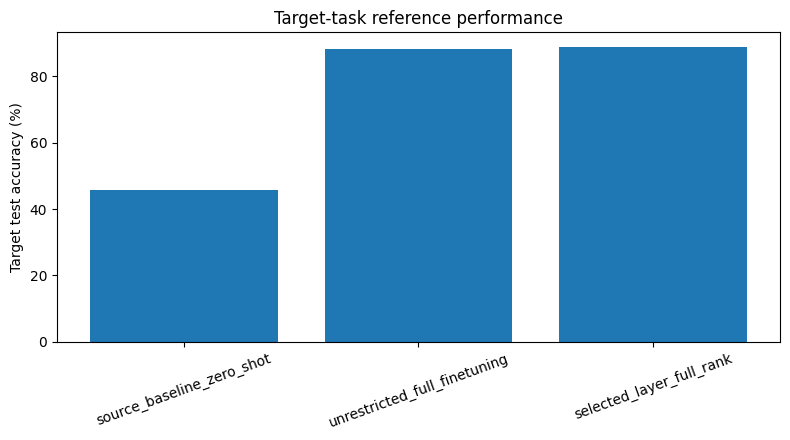

In [145]:
# Figure A: target-task reference performance.
reference_data = pd.read_csv(RESULTS_DIR / "target_reference_metrics.csv")
figure, axis = plt.subplots(figsize=(8, 4.5))
axis.bar(reference_data["method"], 100 * reference_data["target_test_accuracy"])
axis.set_ylabel("Target test accuracy (%)")
axis.set_title("Target-task reference performance")
axis.tick_params(axis="x", rotation=20)
figure.tight_layout()
save_figure(figure, ADAPTATION_FIGURE_DIR, "target_reference_performance")
plt.show()


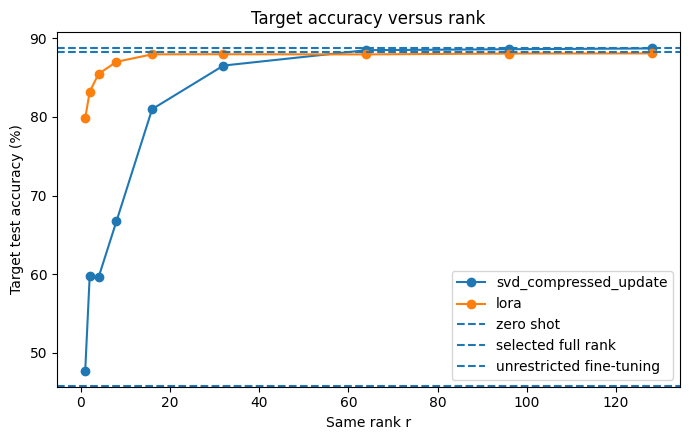

In [146]:
# Figure D: target accuracy versus same rank.
adaptation_data = pd.read_csv(RESULTS_DIR / "adaptation_comparison.csv")
figure, axis = plt.subplots(figsize=(7, 4.5))
for method in ("svd_compressed_update", "lora"):
    method_data = adaptation_data[
        (adaptation_data["method"] == method)
        & adaptation_data["configuration_tags"].str.contains("same_rank")
        & (adaptation_data["rank_w1"] == adaptation_data["rank_w2"])
    ].sort_values("rank_w1")
    axis.plot(
        method_data["rank_w1"],
        100 * method_data["target_test_accuracy"],
        marker="o",
        label=method,
    )
axis.axhline(100 * zero_shot_metrics["target_test_accuracy"], linestyle="--", label="zero shot")
axis.axhline(100 * selected_metrics["target_test_accuracy"], linestyle="--", label="selected full rank")
axis.axhline(100 * unrestricted_metrics["target_test_accuracy"], linestyle="--", label="unrestricted fine-tuning")
axis.set_xlabel("Same rank r")
axis.set_ylabel("Target test accuracy (%)")
axis.set_title("Target accuracy versus rank")
axis.legend()
figure.tight_layout()
save_figure(figure, ADAPTATION_FIGURE_DIR, "target_accuracy_vs_rank")
plt.show()


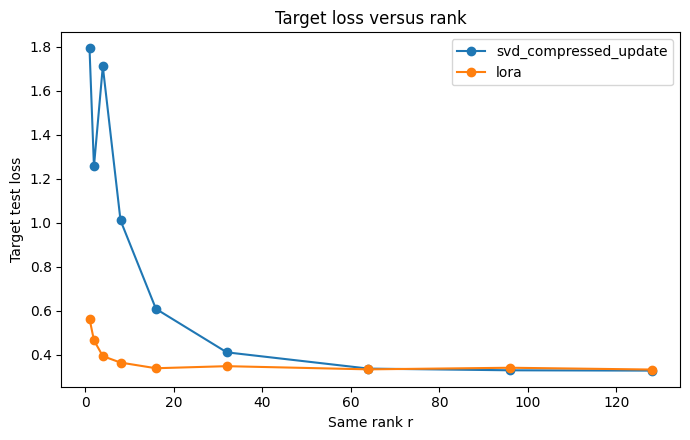

In [147]:
# Figure E: target loss versus same rank.
adaptation_data = pd.read_csv(RESULTS_DIR / "adaptation_comparison.csv")
figure, axis = plt.subplots(figsize=(7, 4.5))
for method in ("svd_compressed_update", "lora"):
    method_data = adaptation_data[
        (adaptation_data["method"] == method)
        & adaptation_data["configuration_tags"].str.contains("same_rank")
        & (adaptation_data["rank_w1"] == adaptation_data["rank_w2"])
    ].sort_values("rank_w1")
    axis.plot(
        method_data["rank_w1"],
        method_data["target_test_loss"],
        marker="o",
        label=method,
    )
axis.set_xlabel("Same rank r")
axis.set_ylabel("Target test loss")
axis.set_title("Target loss versus rank")
axis.legend()
figure.tight_layout()
save_figure(figure, ADAPTATION_FIGURE_DIR, "target_loss_vs_rank")
plt.show()


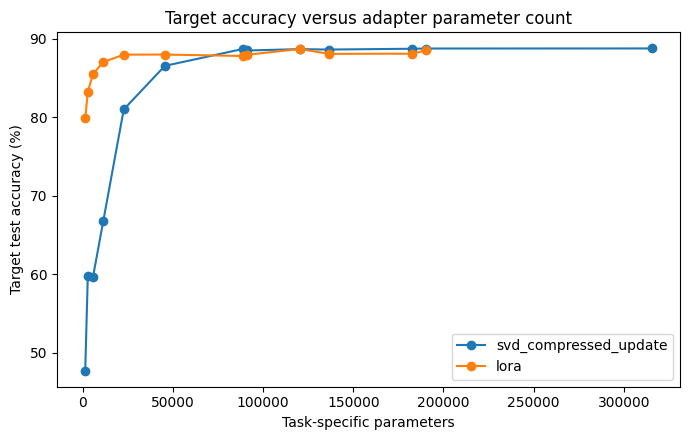

In [148]:
# Figure F: target accuracy versus task-specific parameter count.
adaptation_data = pd.read_csv(RESULTS_DIR / "adaptation_comparison.csv")
figure, axis = plt.subplots(figsize=(7, 4.5))
for method in ("svd_compressed_update", "lora"):
    method_data = adaptation_data[adaptation_data["method"] == method].sort_values(
        "task_specific_stored_parameters"
    )
    axis.plot(
        method_data["task_specific_stored_parameters"],
        100 * method_data["target_test_accuracy"],
        marker="o",
        label=method,
    )
axis.set_xlabel("Task-specific parameters")
axis.set_ylabel("Target test accuracy (%)")
axis.set_title("Target accuracy versus adapter parameter count")
axis.legend()
figure.tight_layout()
save_figure(figure, ADAPTATION_FIGURE_DIR, "target_accuracy_vs_adapter_parameters")
plt.show()


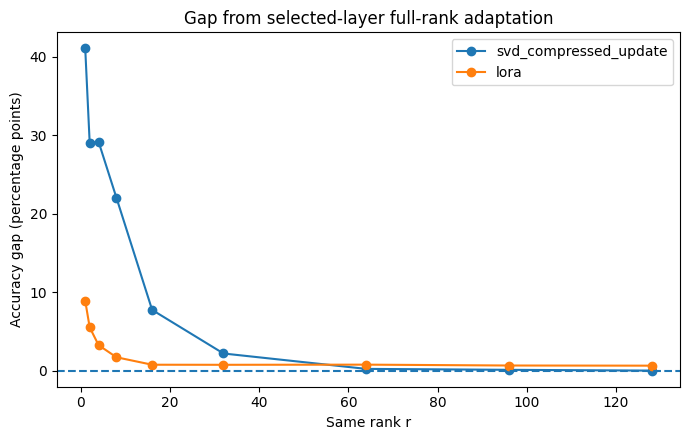

In [149]:
# Figure G: accuracy gap from selected full-rank adaptation.
adaptation_data = pd.read_csv(RESULTS_DIR / "adaptation_comparison.csv")
figure, axis = plt.subplots(figsize=(7, 4.5))
for method in ("svd_compressed_update", "lora"):
    method_data = adaptation_data[
        (adaptation_data["method"] == method)
        & adaptation_data["configuration_tags"].str.contains("same_rank")
        & (adaptation_data["rank_w1"] == adaptation_data["rank_w2"])
    ].sort_values("rank_w1")
    axis.plot(
        method_data["rank_w1"],
        method_data["target_accuracy_gap_from_selected_full_rank_pp"],
        marker="o",
        label=method,
    )
axis.axhline(0.0, linestyle="--")
axis.set_xlabel("Same rank r")
axis.set_ylabel("Accuracy gap (percentage points)")
axis.set_title("Gap from selected-layer full-rank adaptation")
axis.legend()
figure.tight_layout()
save_figure(figure, ADAPTATION_FIGURE_DIR, "accuracy_gap_vs_rank")
plt.show()


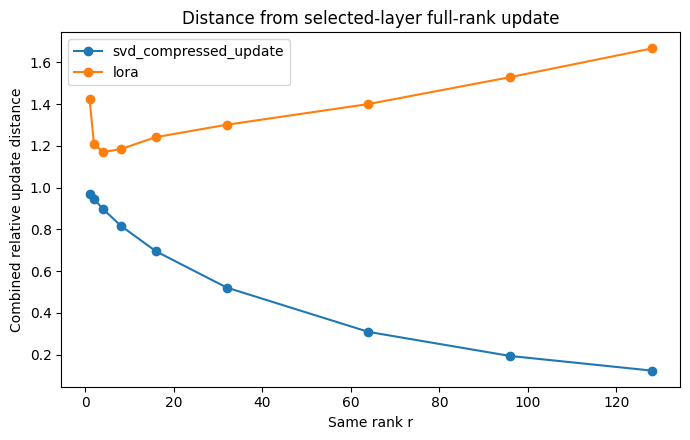

In [150]:
# Figure H: distance from the selected full-rank update.
adaptation_data = pd.read_csv(RESULTS_DIR / "adaptation_comparison.csv")
figure, axis = plt.subplots(figsize=(7, 4.5))
for method in ("svd_compressed_update", "lora"):
    method_data = adaptation_data[
        (adaptation_data["method"] == method)
        & adaptation_data["configuration_tags"].str.contains("same_rank")
        & (adaptation_data["rank_w1"] == adaptation_data["rank_w2"])
    ].sort_values("rank_w1")
    axis.plot(
        method_data["rank_w1"],
        method_data["combined_relative_update_distance"],
        marker="o",
        label=method,
    )
axis.set_xlabel("Same rank r")
axis.set_ylabel("Combined relative update distance")
axis.set_title("Distance from selected-layer full-rank update")
axis.legend()
figure.tight_layout()
save_figure(figure, ADAPTATION_FIGURE_DIR, "update_distance_vs_rank")
plt.show()


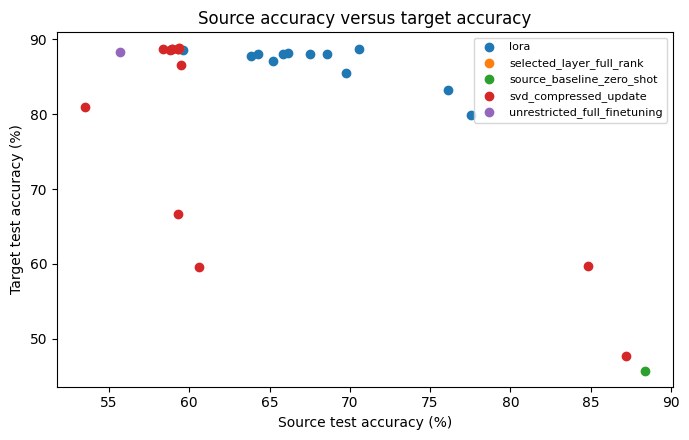

In [151]:
# Figure I: source-retention versus target-adaptation tradeoff.
adaptation_data = pd.read_csv(RESULTS_DIR / "adaptation_comparison.csv")
figure, axis = plt.subplots(figsize=(7, 4.5))
for method, method_data in adaptation_data.groupby("method"):
    axis.scatter(
        100 * method_data["source_test_accuracy"],
        100 * method_data["target_test_accuracy"],
        label=method,
    )
axis.set_xlabel("Source test accuracy (%)")
axis.set_ylabel("Target test accuracy (%)")
axis.set_title("Source accuracy versus target accuracy")
axis.legend(fontsize=8)
figure.tight_layout()
save_figure(figure, ADAPTATION_FIGURE_DIR, "source_target_accuracy_tradeoff")
plt.show()


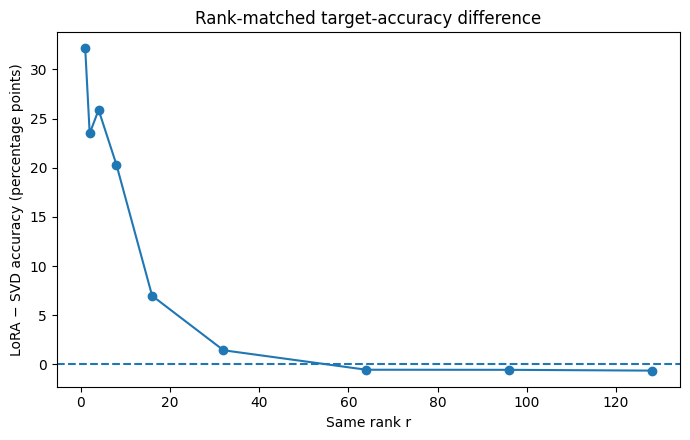

In [152]:
# Figure J: LoRA minus SVD target accuracy.
pair_data = pd.read_csv(RESULTS_DIR / "pairwise_svd_vs_lora.csv")
same_rank_pair_data = pair_data[pair_data["rank_w1"] == pair_data["rank_w2"]].sort_values("rank_w1")
figure, axis = plt.subplots(figsize=(7, 4.5))
axis.plot(
    same_rank_pair_data["rank_w1"],
    same_rank_pair_data["lora_minus_svd_target_accuracy_pp"],
    marker="o",
)
axis.axhline(0.0, linestyle="--")
axis.set_xlabel("Same rank r")
axis.set_ylabel("LoRA − SVD accuracy (percentage points)")
axis.set_title("Rank-matched target-accuracy difference")
figure.tight_layout()
save_figure(figure, ADAPTATION_FIGURE_DIR, "lora_minus_svd_accuracy_vs_rank")
plt.show()


# 22. Final correctness audit and packaging

In [153]:
validation_messages: List[str] = []

def record_check(condition: bool, message: str) -> None:
    if not condition:
        raise AssertionError(message)
    validation_messages.append(f"PASS: {message}")


# Canonical checkpoint remains unchanged.
current_source_payload = load_checked_checkpoint(source_checkpoint_path)
record_check(
    state_dict_digest(current_source_payload["model_state_dict"]) == W0_DIGEST,
    "Canonical source checkpoint remained unchanged.",
)
record_check(
    parameter_counts(source_model)["total"] == BASELINE_PARAMETER_COUNT,
    "Baseline total parameter count is exactly 235,146.",
)
record_check(
    parameter_counts(selected_model)["trainable"] == SELECTED_WEIGHT_PARAMETER_COUNT,
    "Selected-layer reference has exactly 233,472 trainable parameters.",
)


In [154]:
# Expected same-rank adaptation coverage and SVD/LoRA pairability.
svd_saved = pd.read_csv(RESULTS_DIR / "svd_update_sweep.csv")
lora_saved = pd.read_csv(RESULTS_DIR / "lora_sweep.csv")
pair_saved = pd.read_csv(RESULTS_DIR / "pairwise_svd_vs_lora.csv")
expected_same_ranks = set(CONFIG["adaptation_same_rank_grid"])
svd_same_ranks = set(
    svd_saved[
        (svd_saved["rank_w1"] == svd_saved["rank_w2"])
        & svd_saved["configuration_tags"].str.contains("same_rank")
    ]["rank_w1"].astype(int)
)
lora_same_ranks = set(
    lora_saved[
        (lora_saved["rank_w1"] == lora_saved["rank_w2"])
        & lora_saved["configuration_tags"].str.contains("same_rank")
    ]["rank_w1"].astype(int)
)
record_check(svd_same_ranks == expected_same_ranks, "Every expected SVD same-rank row exists.")
record_check(lora_same_ranks == expected_same_ranks, "Every expected LoRA same-rank row exists.")
record_check(len(pair_saved) > 0, "SVD and LoRA rows pair successfully by rank.")


In [155]:
# No missing metrics in final result tables.
key_result_files = [
    "compression_sweep.csv",
    "target_reference_metrics.csv",
    "svd_update_sweep.csv",
    "lora_sweep.csv",
    "adaptation_comparison.csv",
    "pairwise_svd_vs_lora.csv",
    "all_model_evaluations.csv",
]
for filename in key_result_files:
    table = pd.read_csv(RESULTS_DIR / filename)
    record_check(not table.isna().any().any(), f"{filename} contains no missing values or NaNs.")


In [156]:
# Required output files and figure formats.
required_paths = [
    CONFIG_DIR / "experiment_config.json",
    CONFIG_DIR / "environment.txt",
    CONFIG_DIR / "train_indices.pt",
    CONFIG_DIR / "validation_indices.pt",
    CHECKPOINT_DIR / "source_baseline.pt",
    CHECKPOINT_DIR / "target_unrestricted_finetuning.pt",
    CHECKPOINT_DIR / "target_selected_full_rank.pt",
    RESULTS_DIR / "baseline_metrics.json",
    RESULTS_DIR / "baseline_weight_singular_values.csv",
    RESULTS_DIR / "baseline_weight_energy_thresholds.csv",
    RESULTS_DIR / "baseline_weight_rank_metrics.csv",
    RESULTS_DIR / "compression_sweep.csv",
    RESULTS_DIR / "target_reference_metrics.csv",
    RESULTS_DIR / "update_singular_values.csv",
    RESULTS_DIR / "update_energy_thresholds.csv",
    RESULTS_DIR / "update_rank_metrics.csv",
    RESULTS_DIR / "svd_update_sweep.csv",
    RESULTS_DIR / "lora_sweep.csv",
    RESULTS_DIR / "adaptation_comparison.csv",
    RESULTS_DIR / "all_model_evaluations.csv",
]
for path in required_paths:
    record_check(path.exists(), f"Required output exists: {path.relative_to(RUN_ROOT)}")

for figure_directory in (SOURCE_FIGURE_DIR, ADAPTATION_FIGURE_DIR):
    pdf_stems = {path.stem for path in figure_directory.glob("*.pdf")}
    png_stems = {path.stem for path in figure_directory.glob("*.png")}
    record_check(pdf_stems == png_stems, f"Every figure in {figure_directory.name} has PDF and PNG versions.")


In [157]:
validation_log_path = LOG_DIR / "validation_checks.txt"
validation_log_path.write_text("\n".join(validation_messages) + "\n", encoding="utf-8")

summary_lines = [
    f"Configuration signature: {CONFIG_SIGNATURE}",
    f"FAST_DEV_RUN: {CONFIG['fast_dev_run']}",
    f"Device: {DEVICE}",
    f"Source baseline test accuracy: {100 * baseline_metrics['source_test_accuracy']:.4f}%",
    f"Zero-shot target test accuracy: {100 * zero_shot_metrics['target_test_accuracy']:.4f}%",
    f"Unrestricted target test accuracy: {100 * unrestricted_metrics['target_test_accuracy']:.4f}%",
    f"Selected-layer target test accuracy: {100 * selected_metrics['target_test_accuracy']:.4f}%",
    f"Selected LoRA learning rate: {LORA_LEARNING_RATE:g}",
    f"Compression rows: {len(compression_results)}",
    f"SVD update rows: {len(svd_update_results)}",
    f"LoRA rows: {len(lora_results)}",
    f"Validation checks passed: {len(validation_messages)}",
]
summary_path = LOG_DIR / "final_run_summary.txt"
summary_path.write_text("\n".join(summary_lines) + "\n", encoding="utf-8")
print("\n".join(summary_lines))


Configuration signature: 27036506a35f2930
FAST_DEV_RUN: False
Device: cpu
Source baseline test accuracy: 88.3800%
Zero-shot target test accuracy: 45.7700%
Unrestricted target test accuracy: 88.2600%
Selected-layer target test accuracy: 88.7700%
Selected LoRA learning rate: 0.001
Compression rows: 57
SVD update rows: 13
LoRA rows: 12
Validation checks passed: 35


In [158]:
# Create a final archive beside the project directory. In development mode,
# the archive name is explicitly marked as development.
archive_suffix = "development" if CONFIG["fast_dev_run"] else "final_results"
archive_base = PROJECT_ROOT.parent / f"{PROJECT_ROOT.name}_{archive_suffix}"
archive_path = Path(
    shutil.make_archive(str(archive_base), "zip", root_dir=RUN_ROOT)
)
print(f"Archive created: {archive_path}")
print("Notebook execution is complete only after this cell runs without error.")


Archive created: /Users/arhaan/Downloads/MATH110_low_rank_combined_final_results.zip
Notebook execution is complete only after this cell runs without error.
